In [1]:
#!/usr/bin/env python3
import os, glob, re, math, textwrap
from pathlib import Path
from collections import Counter
from typing import Optional, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from matplotlib import font_manager, rcParams
from matplotlib.lines import Line2D
import seaborn as sns
# Path to your font directory
font_dir = "/data1/morrisq/yuj13/share/fonts/liberation-fonts-ttf-2.1.5/"

# Register the font files with Matplotlib
font_manager.fontManager.addfont(font_dir + "LiberationSans-Regular.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Bold.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Italic.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-BoldItalic.ttf")

# Set Liberation Sans as the default font (Arial-compatible)
rcParams["font.family"] = "Liberation Sans"
def read_tsv_skip_comments(path: str) -> pd.DataFrame:
    return pd.read_csv(path, sep="\t", comment="#", dtype=str, low_memory=False)

def pick_col(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    # case-insensitive pick
    cols_lower = {c.lower(): c for c in df.columns}
    for want in candidates:
        if want in df.columns:
            return want
        if want.lower() in cols_lower:
            return cols_lower[want.lower()]
    return None

def extract_sample_and_cancer(df: pd.DataFrame, label: str) -> pd.DataFrame:
    # Prefer detailed type; then broader; fall back if needed.
    sid = pick_col(df, ["SAMPLE_ID", "SAMPLE", "SAMPLEID", "SAMPLE_ID_PRIMARY"])
    cancer = pick_col(df, ["CANCER_TYPE", "PRIMARY_SITE", "DISEASE", "ONCOTREE_CODE"])
    if sid is None or cancer is None:
        print(f"[WARN] {label}: missing SAMPLE_ID or cancer-type column; skipping.")
        return pd.DataFrame(columns=["SAMPLE_ID", "CANCER_TYPE"])
    out = df[[sid, cancer]].rename(columns={sid: "SAMPLE_ID", cancer: "CANCER_TYPE"})
    out["SAMPLE_ID"] = out["SAMPLE_ID"].astype(str).str.strip()
    out["CANCER_TYPE"] = out["CANCER_TYPE"].astype(str).str.strip()
    return out

def build_sampleid_to_cancer(sample_paths: List[str]) -> pd.DataFrame:
    parts = []
    for p in sample_paths:
        df = read_tsv_skip_comments(p)
        parts.append(extract_sample_and_cancer(df, os.path.basename(p)))
    both = pd.concat(parts, ignore_index=True)
    if both.empty:
        raise ValueError("Could not extract SAMPLE_ID + CANCER_TYPE from the two sample TSVs.")
    # collapse to one CANCER_TYPE per SAMPLE_ID (most frequent non-null)
    def choose_ct(series):
        vals = [v for v in series.dropna().astype(str) if v and v.lower() != "nan"]
        if not vals: return np.nan
        return Counter(vals).most_common(1)[0][0]
    return both.groupby("SAMPLE_ID", as_index=False)["CANCER_TYPE"].agg(choose_ct)

In [2]:
def create_model_boxplot_with_dots(
    metrics_df,
    metric_col='accuracy',
    model_col='model',
    cancer_type_col='cancer_type',
    models_to_include=None,
    model_display_names=None,
    model_colors=None,
    figsize=(12, 8),
    y_label=None,
    title=None,
    y_lim=None,
    fontsize=14,
    dot_alpha=0.6,
    dot_size=80,
    jitter_strength=0.2
):
    """
    Create a box plot where x-axis is each model and y-axis is the distribution
    of stratified cancer type metrics. Overlays individual cancer type dots.

    Args:
        metrics_df: DataFrame with columns [model, cancer_type, metric_value]
        metric_col: Name of the column containing the metric values (e.g., 'accuracy', 'f1')
        model_col: Name of the column containing model names
        cancer_type_col: Name of the column containing cancer type labels
        models_to_include: List of model names to include
        model_display_names: Dictionary mapping model names to display names
        model_colors: Dictionary mapping model names to colors
        figsize: Figure size as (width, height)
        y_label: Label for y-axis
        title: Plot title
        y_lim: Y-axis limits as (min, max)
        fontsize: Base font size
        dot_alpha: Transparency for individual dots
        dot_size: Size of individual cancer type dots
        jitter_strength: Amount of horizontal jitter for dots

    Returns:
        matplotlib Figure object
    """
    # Default display names
    default_display_names = {
        'AlphaMissense': 'AlphaMissense',
        'gpt-5': 'GPT-5',
        'claude-opus-45': 'Claude Opus 4.5',
        'deepseek-r1': 'DeepSeek-R1',
        'qwen3-vl-235b-a22b': 'Qwen3-235B',
        'medgemma': 'MedGemma-27B'
    }

    # Default colors
    default_colors = {
        'AlphaMissense': '#000000',
        'gpt-5': '#f97316',
        'claude-opus-45': '#3232a8',
        'deepseek-r1': '#ffb343',
        'qwen3-vl-235b-a22b': '#8b5cf6',
        'medgemma': '#10b981'
    }

    if model_display_names is None:
        model_display_names = default_display_names
    if model_colors is None:
        model_colors = default_colors

    # Filter and sort data
    df = metrics_df.copy()
    if models_to_include is not None:
        df = df[df[model_col].isin(models_to_include)]
    else:
        models_to_include = df[model_col].unique().tolist()

    df[model_col] = pd.Categorical(df[model_col], categories=models_to_include, ordered=True)
    df = df.sort_values(model_col)

    # Create figure
    fig, ax = plt.subplots(figsize=figsize, dpi=150)

    # Prepare data for box plots
    data_by_model = [df[df[model_col] == model][metric_col].dropna().values
                     for model in models_to_include]

    positions = np.arange(len(models_to_include))

    # Create box plots
    bp = ax.boxplot(
        data_by_model,
        positions=positions,
        widths=0.5,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color='darkred', linewidth=3),
        boxprops=dict(alpha=0.85),
        whiskerprops=dict(linewidth=2),
        capprops=dict(linewidth=2)
    )

    # Color boxes
    for patch, model in zip(bp['boxes'], models_to_include):
        color = model_colors.get(model, '#6b7280')
        patch.set_facecolor(color)
        patch.set_edgecolor('black')
        patch.set_linewidth(2)

    # Add jittered dots
    np.random.seed(42)
    for i, model in enumerate(models_to_include):
        model_data = df[df[model_col] == model]
        y_values = model_data[metric_col].values
        jitter = np.random.uniform(-jitter_strength, jitter_strength, size=len(y_values))
        x_values = np.ones(len(y_values)) * i + jitter

        color = model_colors.get(model, '#6b7280')
        ax.scatter(
            x_values, y_values,
            alpha=dot_alpha,
            s=dot_size,
            color=color,
            edgecolors='white',
            linewidth=1,
            zorder=3
        )

    # Formatting
    ax.set_xticks(positions)
    display_labels = [model_display_names.get(m, m) for m in models_to_include]
    ax.set_xticklabels(display_labels, rotation=45, ha='right', fontsize=fontsize)

    if y_label is None:
        y_label = metric_col.replace('_', ' ').title()
        if metric_col == 'accuracy':
            y_label += ' (%)'
    ax.set_ylabel(y_label, fontsize=fontsize + 2, fontweight='bold')

    if title is None:
        title = f'{metric_col.replace("_", " ").title()} Distribution Across Cancer Types'
    ax.set_title(title, fontsize=fontsize + 4, fontweight='bold', pad=20)

    if y_lim is not None:
        ax.set_ylim(y_lim)

    ax.tick_params(axis='y', labelsize=fontsize)
    ax.grid(axis='y', alpha=0.3, linestyle='--', zorder=0)

    plt.tight_layout()
    return fig


def create_gene_performance_plot(
    metrics_df,
    df,
    gene_col='gene',
    top_n=20,
    figsize=(20, 10),
    jitter_amount=0.4,
    y_min=80,
    models_to_include=None,
    metric='accuracy',
    legend_position='right',
    fontsize=18,
    ground_truth_label='ground_truth',
    overall_perf=False
):
    """
    Create gene performance visualization showing stratified performance by gene
    Similar to create_accuracy_plot but stratified by gene instead of cancer type

    Args:
        metrics_df: DataFrame with metrics by gene (must have gene_col and metric columns)
        df: Original dataframe with all predictions for overall metric calculation
        gene_col: Name of the gene column (e.g., 'Hugo_Symbol' or 'gene')
        top_n: Number of top genes to show
        figsize: Figure size
        jitter_amount: Amount of horizontal jitter (0-1, higher = more spread)
        y_min: Minimum value for y-axis (to zoom in on the data)
        models_to_include: List of model names to include in the plot. If None, uses all models
        metric: Metric to display ('accuracy', 'f1', 'precision', 'recall')
        legend_position: Position of legend ('left' or 'right') outside the main plot
        fontsize: Base font size for labels and text
        ground_truth_label: Name of ground truth column
    """
    # Define display names mapping
    display_names = {
        'AlphaMissense': 'AlphaMissense',
        'gpt-5': 'GPT-5',
        'claude-opus-45': 'Claude Opus 4.5',
        'deepseek-r1': 'DeepSeek-R1',
        'qwen3-vl-235b-a22b': 'Qwen3-235B',
        'medgemma': 'MedGemma-27B'
    }

    # Metric display names
    metric_display = {
        'accuracy': 'Accuracy',
        'f1': 'F1 Score',
        'precision': 'Precision',
        'recall': 'Recall'
    }

    # Determine which models to include
    if models_to_include is None:
        models_to_plot = metrics_df['model'].unique().tolist()
    else:
        models_to_plot = models_to_include

    # Calculate overall metric for selected models
    overall_metrics = {}
    for model_name in models_to_plot:
        pred_col = f'{model_name}_pred'
        if pred_col in df.columns and ground_truth_label in df.columns:
            valid_mask = df[pred_col].notna() & df[ground_truth_label].notna()
            if valid_mask.sum() > 0:
                y_true = df.loc[valid_mask, ground_truth_label]
                y_pred = df.loc[valid_mask, pred_col]
                
                if metric == 'accuracy':
                    from sklearn.metrics import accuracy_score
                    metric_value = accuracy_score(y_true, y_pred) * 100
                elif metric == 'f1':
                    from sklearn.metrics import f1_score
                    unique_labels = y_true.unique()
                    if len(unique_labels) == 2:
                        metric_value = f1_score(y_true, y_pred, pos_label=sorted(unique_labels)[1], zero_division=0) * 100
                    else:
                        metric_value = f1_score(y_true, y_pred, average='weighted', zero_division=0) * 100
                elif metric == 'precision':
                    from sklearn.metrics import precision_score
                    unique_labels = y_true.unique()
                    if len(unique_labels) == 2:
                        metric_value = precision_score(y_true, y_pred, pos_label=sorted(unique_labels)[1], zero_division=0) * 100
                    else:
                        metric_value = precision_score(y_true, y_pred, average='weighted', zero_division=0) * 100
                elif metric == 'recall':
                    from sklearn.metrics import recall_score
                    unique_labels = y_true.unique()
                    if len(unique_labels) == 2:
                        metric_value = recall_score(y_true, y_pred, pos_label=sorted(unique_labels)[1], zero_division=0) * 100
                    else:
                        metric_value = recall_score(y_true, y_pred, average='weighted', zero_division=0) * 100
                else:
                    raise ValueError(f"Unknown metric: {metric}")
                
                overall_metrics[model_name] = metric_value

    print(overall_metrics)

    # Get top genes by sample size
    gene_counts = metrics_df.groupby(gene_col)['n_samples'].first().sort_values(ascending=False)
    top_genes = gene_counts.head(top_n).index.tolist()

    # Filter for top genes and selected models
    plot_df = metrics_df[
        (metrics_df[gene_col].isin(top_genes)) &
        (metrics_df['model'].isin(models_to_plot))
    ].copy()

    # Define colors for methods
    colors_methods = {
        'AlphaMissense': '#000000',
        'gpt-5': '#f97316',
        'claude-opus-45': '#3232a8',
        'deepseek-r1': '#ffb343',
        'qwen3-vl-235b-a22b': '#8b5cf6',
        'medgemma': '#10b981'
    }
    default_colors = ['#6b7280','#374151','#d97706','#059669','#dc2626','#7c3aed','#2563eb']
    for i, m in enumerate(models_to_plot):
        if m not in colors_methods:
            colors_methods[m] = default_colors[i % len(default_colors)]

    # Define markers for methods
    markers_cycle = ['o','s','^','D','P','X','*','v','<','>','h','H','d','p']
    method_markers = {
        'AlphaMissense': 'o',
        'gpt-5': 'D',
        'claude-opus-45': '^',
        'deepseek-r1': 'd',
        'qwen3-vl-235b-a22b': 'P',
        'medgemma': '*'
    }

    # Define model styles
    model_styles = {}
    for model in models_to_plot:
        model_styles[model] = {
            'marker': method_markers.get(model, 'o'),
            'color': colors_methods.get(model, '#6b7280'),
            's': 200
        }

    # Create figure with 2 subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize,
                                    gridspec_kw={'height_ratios': [1, 4], 'hspace': 0.1})

    # === Top subplot: Bar showing sample counts ===
    x_positions = np.arange(len(top_genes))
    sample_counts = [gene_counts[gene] for gene in top_genes]

    # Calculate ground truth distribution for each gene
    ground_truth_data = []
    for gene in top_genes:
        gene_df = df[df[gene_col] == gene]
        gt_counts = gene_df[ground_truth_label].value_counts()
        ground_truth_data.append(gt_counts)

    # Get all unique ground truth labels
    all_labels = sorted(set().union(*[set(gt.index) for gt in ground_truth_data]))

    # Define colors for ground truth labels
    gt_colors = {
        'Benign': '#ffe755',
        'Oncogenic': '#3498DB'
    }

    # Create stacked bars
    bottom = np.zeros(len(top_genes))
    for label in all_labels:
        heights = [gt.get(label, 0) for gt in ground_truth_data]
        color = gt_colors.get(label, '#95A5A6')
        ax1.bar(x_positions, heights, bottom=bottom, color=color,
                edgecolor='black', linewidth=0.5, label=label)
        bottom += heights

    # Add total count labels
    for i, (x, count) in enumerate(zip(x_positions, sample_counts)):
        ax1.text(x, count + count*0.05, f'{int(count):,}',
                ha='center', va='bottom', fontsize=fontsize-4, fontweight='bold')

    ax1.set_ylabel('Samples (N)', fontsize=fontsize, fontweight='bold', labelpad=20)
    ax1.set_xlim(-0.5, len(top_genes) - 0.5)
    ax1.set_ylim(0, max(sample_counts) * 1.3)
    ax1.tick_params(axis='both', labelsize=fontsize)
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    ax1.set_xticks([])
    ax1.set_title(f'{metric_display[metric]} Evaluation Across Genes', fontsize=fontsize, fontweight='bold', pad=15)

    # Place ground truth legend outside
    if legend_position == 'right':
        ax1.legend(title='Ground Truth', loc='center left', bbox_to_anchor=(1.01, 0.5), 
                  frameon=True, fontsize=fontsize-4, title_fontsize=fontsize-4)
    else:
        ax1.legend(title='Ground Truth', loc='center right', bbox_to_anchor=(-0.01, 0.5),
                  frameon=True, fontsize=fontsize-4, title_fontsize=fontsize-4)

    # === Bottom subplot: Performance scatter plot ===
    data_min = plot_df[metric].min()
    data_max = plot_df[metric].max()
    y_range = data_max - data_min

    y_bottom = min(y_min, data_min - y_range * 0.05)
    y_top = 100.5 if data_max >= 99.5 else min(100, data_max + y_range * 0.1)

    # Add gray background bars
    for i in range(len(top_genes)):
        ax2.bar(i, y_top - y_bottom, bottom=y_bottom, width=0.8,
               color='lightgray', alpha=0.5, edgecolor='none', zorder=1)
    if overall_perf:
        # Draw horizontal lines for overall performance
        for model_name, overall_metric in overall_metrics.items():
            if model_name in model_styles:
                style = model_styles[model_name]
                ax2.axhline(y=overall_metric, color=style['color'], linestyle='--',
                           alpha=1, linewidth=3, zorder=2)

    # Plot performance points with jittering
    np.random.seed(42)

    for i, gene in enumerate(top_genes):
        gene_data = plot_df[plot_df[gene_col] == gene]
        models_in_gene = gene_data['model'].unique()
        n_models = len(models_in_gene)

        if n_models > 1:
            jitter_positions = np.linspace(-jitter_amount/2, jitter_amount/2, n_models)
        else:
            jitter_positions = [0]

        model_to_jitter = dict(zip(models_in_gene, jitter_positions))

        for _, row in gene_data.iterrows():
            model = row['model']
            if model in model_styles:
                style = model_styles[model]
                x_offset = model_to_jitter.get(model, 0)
                x_offset += np.random.uniform(-0.02, 0.02)

                ax2.scatter(i + x_offset, row[metric],
                           marker=style['marker'],
                           color=style['color'],
                           s=style['s'],
                           alpha=0.9,
                           edgecolors=style['color'],
                           linewidth=0.6,
                           zorder=2)

    # Formatting
    if metric == "accuracy":
        ax2.set_ylabel(f'{metric_display[metric]} (%)', fontsize=fontsize, fontweight='bold')
    else:
        ax2.set_ylabel(f'{metric_display[metric]}', fontsize=fontsize, fontweight='bold')
    ax2.set_xlim(-0.5, len(top_genes) - 0.5)
    ax2.set_ylim(y_bottom, y_top)

    # X-axis labels
    ax2.set_xticks(x_positions)
    ax2.set_xticklabels(top_genes, rotation=45, ha='right', fontsize=fontsize)
    ax2.tick_params(axis='y', labelsize=fontsize)

    # Vertical separators
    for i in range(1, len(top_genes)):
        ax2.axvline(x=i-0.5, color='white', linestyle='-', alpha=0.8, linewidth=1, zorder=3)
        ax1.axvline(x=i-0.5, color='gray', linestyle='-', alpha=0.15, linewidth=0.5)

    # Legend
    legend_elements = []

    for model in models_to_plot:
        if model in model_styles:
            style = model_styles[model]
            display_name = display_names.get(model, model)
            legend_elements.append(
                plt.Line2D([0], [0], marker=style['marker'], color='w',
                          markerfacecolor=style['color'], markersize=10,
                          label=display_name, markeredgecolor='black', markeredgewidth=0.5)
            )
    if overall_perf:
        legend_elements.append(plt.Line2D([0], [0], color='none', label=''))
        legend_elements.append(plt.Line2D([0], [0], color='none',
                                          label=f'--- Overall Performance ---'))
    
        for model in models_to_plot:
            if model in model_styles and model in overall_metrics:
                style = model_styles[model]
                display_name = display_names.get(model, model)
                if metric == "accuracy":
                    legend_elements.append(
                        plt.Line2D([0], [0], color=style['color'], linewidth=2, linestyle='--',
                                  label=f'{display_name}: {overall_metrics[model]:.2f}%', alpha=0.6)
                    )
                else:
                    legend_elements.append(
                        plt.Line2D([0], [0], color=style['color'], linewidth=2, linestyle='--',
                                  label=f'{display_name}: {overall_metrics[model]:.2f}', alpha=0.6)
                    )

    if legend_position == 'right':
        ax2.legend(handles=legend_elements, title='Models', title_fontsize=fontsize-4,
                  loc='center left', bbox_to_anchor=(1.01, 0.5),
                  frameon=True, fancybox=True, shadow=True,
                  ncol=1, fontsize=fontsize-4)
    else:
        ax2.legend(handles=legend_elements, title='Models', title_fontsize=fontsize-4,
                  loc='center right', bbox_to_anchor=(-0.01, 0.5),
                  frameon=True, fancybox=True, shadow=True,
                  ncol=1, fontsize=fontsize-4)

    plt.tight_layout()
    return fig

In [3]:
# ---------- CONFIG ----------
BASE_RESULTS_DIR = "/data1/morrisq/yuj13/llm_genomics/mutation_output/impact_oncogenic_sample"
# MODEL_NAMES = ["gpt-5", "medgemma", "qwen3", "claude-sonnet-37", "deepseek", "AlphaMissense"]
MODEL_NAMES = ["gpt-5", "o3-mini", "gpt-4o", "medgemma", "qwen3", "claude-sonnet-37", "claude-sonnet-45", "claude-opus-45", "deepseek", "deepseek-r1", "qwen3-vl-235b-a22b", "AlphaMissense"]
# MODEL_NAMES = ["AlphaMissense", "gpt-5", "claude-opus-45", "deepseek-r1", "qwen3-vl-235b-a22b", "medgemma"]

MODEL_DIRS = [os.path.join(BASE_RESULTS_DIR, x) for x in MODEL_NAMES]

SAMPLE_TSVS = [
    "/data1/morrisq/yuj13/llm_genomics/msk_solid_heme/data_clinical_sample.txt",
]

OUTPUT_DIR = "/data1/morrisq/yuj13/llm_genomics/llm_cancer_type_classification/analysis/2_oncogenic_driver_identification"
OUT_METRICS_DIR = os.path.join(OUTPUT_DIR, "metrics")
OUT_PLOTS_DIR   = os.path.join(OUTPUT_DIR, "plots")

MIN_SAMPLES_PER_CANCER = 10
TOP_N = 25  
# ---------------------------

print("Building SAMPLE_ID → CANCER_TYPE using ONLY the two sample TSVs (concat)…")
samp2ct = build_sampleid_to_cancer(SAMPLE_TSVS)  # only SAMPLE_ID + CANCER_TYPE


Building SAMPLE_ID → CANCER_TYPE using ONLY the two sample TSVs (concat)…


In [4]:
samp2ct

,SAMPLE_ID,CANCER_TYPE
0,P-0000004-T01-IM3,Breast Cancer
1,P-0000012-T02-IM3,Breast Cancer
2,P-0000012-T03-IM3,Non-Small Cell Lung Cancer
3,P-0000012-T04-IM6,Non-Small Cell Lung Cancer
4,P-0000012-T06-IM7,Bladder Cancer
...,...,...
152446,P-0128867-T01-IH4,"Lymphatic Cancer, NOS"
152447,P-0128868-T01-IH4,Mature B-Cell Neoplasms
152448,P-0128869-T01-IH4,NaN
152449,P-0128959-T01-IM7,Soft Tissue Sarcoma


In [5]:
import os
import glob
import pandas as pd

def load_all_model_predictions(
    model_dirs,
    model_names,
    samp2ct,
    ground_truth_label=None,  # e.g. "OncoKB_label" or "CANCER_TYPE"
    gene_col=None,  # e.g. "gene" or "Hugo_Symbol"
):
    print("Loading model predictions and merging with cancer types...")
    merged_df = None
    gt_set = False
    gene_set = False
    gene_col_name = None  # Track the actual gene column name found

    for model_name, model_dir in zip(model_names, model_dirs):
        print(f"Loading {model_name} predictions from {model_dir}")

        csv_files = sorted(glob.glob(os.path.join(model_dir, "*.csv")))
        if not csv_files:
            print(f"  Warning: no CSV files found for {model_name}")
            continue

        model_dfs = []
        for csv_file in csv_files:
            try:
                df_batch = pd.read_csv(csv_file)
                model_dfs.append(df_batch)
            except Exception as e:
                print(f"  Error reading {csv_file}: {e}")

        if not model_dfs:
            continue

        model_df = pd.concat(model_dfs, ignore_index=True)
        print(f"  Loaded {len(model_df)} rows from {len(csv_files)} files")

        # keep only the columns we need
        keep_cols = ["mutation_id", "SAMPLE_ID", "prediction", "prob"]
        if ground_truth_label and ground_truth_label in model_df.columns:
            keep_cols.append(ground_truth_label)
        
        # Add gene column if specified
        if gene_col and not gene_set:
            # Try common gene column names
            possible_gene_cols = [gene_col, 'gene', 'Gene', 'Hugo_Symbol', 'HUGO_SYMBOL']
            for col in possible_gene_cols:
                if col in model_df.columns:
                    gene_col_name = col  # Remember the actual column name
                    if col not in keep_cols:
                        keep_cols.append(col)
                    break
        elif gene_col and gene_set and gene_col_name:
            # Gene column already found in previous iteration
            if gene_col_name in model_df.columns:
                if gene_col_name not in keep_cols:
                    keep_cols.append(gene_col_name)
        
        model_df = model_df[keep_cols].copy()

        # *** collapse duplicates: one row per mutation_id + SAMPLE_ID ***
        before = len(model_df)
        model_df = (
            model_df
            .groupby(["mutation_id", "SAMPLE_ID"], as_index=False)
            .first()  # take the first row if there were multiple
        )
        after = len(model_df)
        if after < before:
            print(f"  Deduplicated {before - after} rows for {model_name}")

        print(
            f"  {model_name}: {after} unique mutation/sample pairs"
        )

        # rename prediction / prob to model-specific columns
        model_df = model_df.rename(
            columns={
                "prediction": f"{model_name}_pred",
                "prob": f"{model_name}_prob",
            }
        )

        # normalize ground truth column name once
        if ground_truth_label and ground_truth_label in keep_cols:
            if not gt_set:
                model_df = model_df.rename(
                    columns={ground_truth_label: "ground_truth"}
                )
                gt_set = True
            else:
                # ground truth already added from another model; drop here
                if ground_truth_label in model_df.columns:
                    model_df = model_df.drop(columns=[ground_truth_label])
        
        # normalize gene column name once (rename to standard 'gene')
        if gene_col_name and not gene_set:
            model_df = model_df.rename(columns={gene_col_name: "gene"})
            gene_set = True
        elif gene_col_name and gene_set:
            # Gene already normalized in previous iteration, rename this one too
            if gene_col_name in model_df.columns:
                model_df = model_df.rename(columns={gene_col_name: "gene"})

        # merge models on mutation_id + SAMPLE_ID
        if merged_df is None:
            merged_df = model_df
        else:
            # Determine merge columns - include gene if it's present in both
            merge_cols = ["mutation_id", "SAMPLE_ID"]
            if "gene" in merged_df.columns and "gene" in model_df.columns:
                merge_cols.append("gene")
            
            merged_df = merged_df.merge(
                model_df,
                on=merge_cols,
                how="inner",
            )

        print(f"  -> merged_df now has {len(merged_df)} rows\n")

    if merged_df is None:
        print("No model predictions loaded.")
        return None

    # attach cancer type
    merged_df = merged_df.merge(
        samp2ct[["SAMPLE_ID", "CANCER_TYPE"]],
        on="SAMPLE_ID",
        how="left",
    )

    # optional final safety dedup
    merged_df = (
        merged_df
        .sort_values(["mutation_id", "SAMPLE_ID"])
        .drop_duplicates(subset=["mutation_id", "SAMPLE_ID"], keep="first")
    )
    print(f"Final merged_df has {len(merged_df)} unique mutation/sample rows")

    # AlphaMissense filter
    if "AlphaMissense" in model_names and "AlphaMissense_pred" in merged_df.columns:
        merged_df = merged_df[merged_df["AlphaMissense_pred"] != "VUS"]

    return merged_df


def calculate_metrics_by_cancer_type(df, model_names, ground_truth_label="ground_truth", min_samples=10, metric='accuracy'):
    """
    Calculate metrics for each model by cancer type
    
    Args:
        df: DataFrame with predictions and ground truth
        model_names: List of model names
        min_samples: Minimum number of samples required per cancer type
        metric: Metric to calculate ('accuracy', 'f1', 'precision', 'recall')
    
    Returns:
        DataFrame with metrics by cancer type
    """
    results = []
    
    # Filter out UNKNOWN cancer types
    df_filtered = df[df['CANCER_TYPE'] != 'UNKNOWN'].copy()
    
    # Get cancer types with sufficient samples
    cancer_counts = df_filtered['CANCER_TYPE'].value_counts()
    valid_cancers = cancer_counts[cancer_counts >= min_samples].index
    
    for cancer_type in valid_cancers:
        cancer_df = df_filtered[df_filtered['CANCER_TYPE'] == cancer_type]
        n_samples = len(cancer_df)
        
        for model_name in model_names:
            pred_col = f'{model_name}_pred'
            prob_col = f'{model_name}_prob'
            
            if pred_col in df.columns:
                # Get valid predictions (non-null)
                valid_mask = cancer_df[pred_col].notna() & cancer_df[ground_truth_label].notna()
                valid_df = cancer_df[valid_mask]
                
                if len(valid_df) > 0:
                    y_true = valid_df[ground_truth_label]
                    y_pred = valid_df[pred_col]
                    
                    # Calculate the requested metric
                    if metric == 'accuracy':
                        metric_value = accuracy_score(y_true, y_pred) * 100
                    elif metric == 'f1':
                        # For binary classification, use 'binary' average
                        unique_labels = y_true.unique()
                        if len(unique_labels) == 2:
                            metric_value = f1_score(y_true, y_pred, pos_label=sorted(unique_labels)[1], zero_division=0)
                        else:
                            metric_value = f1_score(y_true, y_pred, average='weighted', zero_division=0)
                    elif metric == 'precision':
                        unique_labels = y_true.unique()
                        if len(unique_labels) == 2:
                            metric_value = precision_score(y_true, y_pred, pos_label=sorted(unique_labels)[1], zero_division=0)
                        else:
                            metric_value = precision_score(y_true, y_pred, average='weighted', zero_division=0)
                    elif metric == 'recall':
                        unique_labels = y_true.unique()
                        if len(unique_labels) == 2:
                            metric_value = recall_score(y_true, y_pred, pos_label=sorted(unique_labels)[1], zero_division=0)
                        else:
                            metric_value = recall_score(y_true, y_pred, average='weighted', zero_division=0)
                    else:
                        raise ValueError(f"Unknown metric: {metric}. Choose from 'accuracy', 'f1', 'precision', 'recall'")
                    
                    # Calculate mean probability/confidence
                    mean_prob = valid_df[prob_col].mean() if prob_col in df.columns else np.nan
                    
                    results.append({
                        'cancer_type': cancer_type,
                        'model': model_name,
                        metric: metric_value,
                        'mean_prob': mean_prob,
                        'n_samples': n_samples,
                        'n_valid': len(valid_df)
                    })
                else:
                    print(f"  No valid predictions for {model_name} in {cancer_type}")
    
    return pd.DataFrame(results)


def calculate_metrics_by_gene(df, model_names, gene_col='gene', ground_truth_label="ground_truth", min_samples=10, metric='accuracy'):
    """
    Calculate metrics for each model by gene
    
    Args:
        df: DataFrame with predictions and ground truth
        model_names: List of model names
        gene_col: Name of the gene column (e.g., 'Hugo_Symbol' or 'gene')
        ground_truth_label: Name of ground truth column
        min_samples: Minimum number of samples required per gene
        metric: Metric to calculate ('accuracy', 'f1', 'precision', 'recall')
    
    Returns:
        DataFrame with metrics by gene
    """
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
    
    results = []
    
    # Check if gene column exists
    if gene_col not in df.columns:
        raise ValueError(f"Gene column '{gene_col}' not found in dataframe. Available columns: {df.columns.tolist()}")
    
    # Get genes with sufficient samples
    gene_counts = df[gene_col].value_counts()
    valid_genes = gene_counts[gene_counts >= min_samples].index
    
    for gene in valid_genes:
        gene_df = df[df[gene_col] == gene]
        n_samples = len(gene_df)
        
        for model_name in model_names:
            pred_col = f'{model_name}_pred'
            prob_col = f'{model_name}_prob'
            
            if pred_col in df.columns:
                # Get valid predictions (non-null)
                valid_mask = gene_df[pred_col].notna() & gene_df[ground_truth_label].notna()
                valid_df = gene_df[valid_mask]
                
                if len(valid_df) > 0:
                    y_true = valid_df[ground_truth_label]
                    y_pred = valid_df[pred_col]
                    
                    # Calculate the requested metric
                    if metric == 'accuracy':
                        metric_value = accuracy_score(y_true, y_pred) * 100
                    elif metric == 'f1':
                        unique_labels = y_true.unique()
                        if len(unique_labels) == 2:
                            metric_value = f1_score(y_true, y_pred, pos_label=sorted(unique_labels)[1], zero_division=0) * 100
                        else:
                            metric_value = f1_score(y_true, y_pred, average='weighted', zero_division=0) * 100
                    elif metric == 'precision':
                        unique_labels = y_true.unique()
                        if len(unique_labels) == 2:
                            metric_value = precision_score(y_true, y_pred, pos_label=sorted(unique_labels)[1], zero_division=0) * 100
                        else:
                            metric_value = precision_score(y_true, y_pred, average='weighted', zero_division=0) * 100
                    elif metric == 'recall':
                        unique_labels = y_true.unique()
                        if len(unique_labels) == 2:
                            metric_value = recall_score(y_true, y_pred, pos_label=sorted(unique_labels)[1], zero_division=0) * 100
                        else:
                            metric_value = recall_score(y_true, y_pred, average='weighted', zero_division=0) * 100
                    else:
                        raise ValueError(f"Unknown metric: {metric}. Choose from 'accuracy', 'f1', 'precision', 'recall'")
                    
                    # Calculate mean probability/confidence
                    mean_prob = valid_df[prob_col].mean() if prob_col in df.columns else np.nan
                    
                    results.append({
                        gene_col: gene,
                        'model': model_name,
                        metric: metric_value,
                        'mean_prob': mean_prob,
                        'n_samples': n_samples,
                        'n_valid': len(valid_df)
                    })
                else:
                    print(f"  No valid predictions for {model_name} in gene {gene}")
    
    return pd.DataFrame(results)


def calculate_overall_accuracy(df, model_names, metric='accuracy', ground_truth_label="ground_truth"):
    """
    Calculate overall metric for each model across all samples
    
    Args:
        df: DataFrame with predictions and ground truth
        model_names: List of model names
        metric: Metric to calculate ('accuracy', 'f1', 'precision', 'recall')
    
    Returns:
        Dictionary with metric values for each model
    """
    overall_metrics = {}
    
    for model_name in model_names:
        pred_col = f'{model_name}_pred'
        if pred_col in df.columns and ground_truth_label in df.columns:
            valid_mask = df[pred_col].notna() & df[ground_truth_label].notna()
            if valid_mask.sum() > 0:
                y_true = df.loc[valid_mask, ground_truth_label]
                y_pred = df.loc[valid_mask, pred_col]
                
                if metric == 'accuracy':
                    metric_value = accuracy_score(y_true, y_pred) * 100
                elif metric == 'f1':
                    unique_labels = y_true.unique()
                    if len(unique_labels) == 2:
                        metric_value = f1_score(y_true, y_pred, pos_label=sorted(unique_labels)[1], zero_division=0)
                    else:
                        metric_value = f1_score(y_true, y_pred, average='weighted', zero_division=0)
                elif metric == 'precision':
                    unique_labels = y_true.unique()
                    if len(unique_labels) == 2:
                        metric_value = precision_score(y_true, y_pred, pos_label=sorted(unique_labels)[1], zero_division=0)
                    else:
                        metric_value = precision_score(y_true, y_pred, average='weighted', zero_division=0)
                elif metric == 'recall':
                    unique_labels = y_true.unique()
                    if len(unique_labels) == 2:
                        metric_value = recall_score(y_true, y_pred, pos_label=sorted(unique_labels)[1], zero_division=0)
                    else:
                        metric_value = recall_score(y_true, y_pred, average='weighted', zero_division=0)
                else:
                    raise ValueError(f"Unknown metric: {metric}. Choose from 'accuracy', 'f1', 'precision', 'recall'")
                
                overall_metrics[model_name] = metric_value
    
    return overall_metrics

def create_accuracy_plot(metrics_df, df, top_n=20, figsize=(20, 10), jitter_amount=0.4, y_min=80,
                        models_to_include=None, metric='accuracy', legend_position='right', fontsize=18, ground_truth_label='ground_truth', overall_perf=False):
    """
    Create accuracy visualization with stacked bar showing ground truth distribution and adjusted y-axis for 100% visibility

    Args:
        metrics_df: DataFrame with accuracy metrics by cancer type
        df: Original dataframe with all predictions for overall accuracy calculation
        top_n: Number of top cancer types to show
        figsize: Figure size
        jitter_amount: Amount of horizontal jitter (0-1, higher = more spread)
        y_min: Minimum value for y-axis (to zoom in on the data)
        models_to_include: List of model names to include in the plot. If None, uses all MODEL_NAMES
        metric: Metric to display ('accuracy', 'f1', 'precision', 'recall')
        legend_position: Position of legend ('left' or 'right') outside the main plot
        fontsize: Base font size for labels and text
    """
    # Define display names mapping
    display_names = {
        'AlphaMissense': 'AlphaMissense',
        'gpt-5': 'GPT-5',
        'claude-opus-45': 'Claude Opus 4.5',
        'deepseek-r1': 'DeepSeek-R1',
        'qwen3-vl-235b-a22b': 'Qwen3-235B',
        'medgemma': 'MedGemma-27B'
    }

    # Metric display names
    metric_display = {
        'accuracy': 'Accuracy',
        'f1': 'F1 Score',
        'precision': 'Precision',
        'recall': 'Recall'
    }

    # Determine which models to include
    if models_to_include is None:
        models_to_plot = MODEL_NAMES
    else:
        models_to_plot = models_to_include

    # Calculate overall metric for selected models
    overall_metrics = calculate_overall_accuracy(df, models_to_plot, ground_truth_label=ground_truth_label, metric=metric)
    print(overall_metrics)

    # Get top cancer types by sample size
    cancer_counts = metrics_df.groupby('cancer_type')['n_samples'].first().sort_values(ascending=False)
    top_cancers = cancer_counts.head(top_n).index.tolist()

    # Filter for top cancer types and selected models
    plot_df = metrics_df[
        (metrics_df['cancer_type'].isin(top_cancers)) &
        (metrics_df['model'].isin(models_to_plot))
    ].copy()

    # Define colors for methods (different orange shades for GPT models)
    colors_methods = {
        'AlphaMissense': '#000000',
        'gpt-5': '#f97316',
        'claude-opus-45': '#3232a8',
        'deepseek-r1': '#ffb343',
        'qwen3-vl-235b-a22b': '#8b5cf6',
        'medgemma': '#10b981'
    }
    default_colors = ['#6b7280','#374151','#d97706','#059669','#dc2626','#7c3aed','#2563eb']
    for i, m in enumerate(models_to_plot):
        if m not in colors_methods:
            colors_methods[m] = default_colors[i % len(default_colors)]

    # Define markers for methods
    markers_cycle = ['o','s','^','D','P','X','*','v','<','>','h','H','d','p']
    method_markers = {
        'AlphaMissense': 'o',
        'gpt-5': 'D',
        'claude-opus-45': '^',
        'deepseek-r1': 'd',
        'qwen3-vl-235b-a22b': 'P',
        'medgemma': '*'
    }

    # Define model styles with colors and markers
    model_styles = {}
    for model in models_to_plot:
        model_styles[model] = {
            'marker': method_markers.get(model, 'o'),
            'color': colors_methods.get(model, '#6b7280'),
            's': 200
        }

    # Create figure with 2 subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize,
                                    gridspec_kw={'height_ratios': [1, 4], 'hspace': 0.1})

    # === Top subplot: Stacked bar showing ground truth distribution ===
    x_positions = np.arange(len(top_cancers))
    sample_counts = [cancer_counts[cancer] for cancer in top_cancers]

    # Calculate ground truth distribution for each cancer type
    ground_truth_data = []
    for cancer in top_cancers:
        cancer_df = df[df['CANCER_TYPE'] == cancer]
        gt_counts = cancer_df[ground_truth_label].value_counts()
        ground_truth_data.append(gt_counts)

    # Get all unique ground truth labels
    all_labels = sorted(set().union(*[set(gt.index) for gt in ground_truth_data]))

    # Define colors for ground truth labels
    gt_colors = {
        'Benign': '#ffe755',        # Yellow
        'Oncogenic': '#3498DB'      # Blue
    }

    # Create stacked bars
    bottom = np.zeros(len(top_cancers))
    for label in all_labels:
        heights = [gt.get(label, 0) for gt in ground_truth_data]
        color = gt_colors.get(label, '#95A5A6')  # Default gray if label not in dict
        ax1.bar(x_positions, heights, bottom=bottom, color=color,
                edgecolor='black', linewidth=0.5, label=label)

        bottom += heights

    # Add total count labels on top of stacked bars
    for i, (x, count) in enumerate(zip(x_positions, sample_counts)):
        ax1.text(x, count + count*0.05, f'{int(count):,}',
                ha='center', va='bottom', fontsize=fontsize-4, fontweight='bold')

    ax1.set_ylabel('Samples (N)', fontsize=fontsize, fontweight='bold', labelpad=20)
    ax1.set_xlim(-0.5, len(top_cancers) - 0.5)
    ax1.set_ylim(100, max(sample_counts) + 500)  # Start at 100
    ax1.tick_params(axis='both', labelsize=fontsize)
    # ax1.set_yscale('log')  # Log scale
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    ax1.set_xticks([])
    ax1.set_title(f'{metric_display[metric]} Evaluation Across Cancer Types', fontsize=fontsize, fontweight='bold', pad=15)

    # Place ground truth legend outside
    if legend_position == 'right':
        ax1.legend(title='Ground Truth', loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=True, fontsize=fontsize-4, title_fontsize=fontsize-4)
    else:  # left
        ax1.legend(title='Ground Truth', loc='center right', bbox_to_anchor=(-0.01, 0.5), frameon=True, fontsize=fontsize-4, title_fontsize=fontsize-4)

    # === Bottom subplot: Accuracy scatter plot ===

    # Calculate y-axis limits
    data_min = plot_df[metric].min()
    data_max = plot_df[metric].max()
    y_range = data_max - data_min

    # Adjust y_max to ensure 100% points are visible
    y_bottom = min(y_min, data_min - y_range * 0.05)
    y_top = 100.5 if data_max >= 99.5 else min(100, data_max + y_range * 0.1)

    # Add gray background bars for each cancer type
    for i in range(len(top_cancers)):
        # Create a gray bar from y_bottom to y_top
        ax2.bar(i, y_top - y_bottom, bottom=y_bottom, width=0.8,
               color='lightgray', alpha=0.5, edgecolor='none', zorder=1)
    if overall_perf:
        # Draw horizontal lines for overall performance
        for model_name, overall_metric in overall_metrics.items():
            if model_name in model_styles:
                style = model_styles[model_name]
                ax2.axhline(y=overall_metric, color=style['color'], linestyle='--',
                           alpha=1, linewidth=3, zorder=2)

    # Plot accuracy points with jittering
    np.random.seed(42)  # For reproducible jittering

    for i, cancer in enumerate(top_cancers):
        cancer_data = plot_df[plot_df['cancer_type'] == cancer]

        # Get unique models for this cancer type
        models_in_cancer = cancer_data['model'].unique()
        n_models = len(models_in_cancer)

        # Create jitter positions for each model
        if n_models > 1:
            jitter_positions = np.linspace(-jitter_amount/2, jitter_amount/2, n_models)
        else:
            jitter_positions = [0]

        # Create a mapping of model to jitter position
        model_to_jitter = dict(zip(models_in_cancer, jitter_positions))

        # Plot each model's performance with controlled jittering
        for _, row in cancer_data.iterrows():
            model = row['model']
            if model in model_styles:
                style = model_styles[model]
                # Use assigned jitter position for this model
                x_offset = model_to_jitter.get(model, 0)
                # Add small random variation to prevent perfect alignment
                x_offset += np.random.uniform(-0.02, 0.02)

                ax2.scatter(i + x_offset, row[metric],
                           marker=style['marker'],
                           color=style['color'],
                           s=style['s'],
                           alpha=0.9,
                           edgecolors=style['color'],
                           linewidth=0.6,
                           zorder=2)

    # Formatting
    if metric == "accuracy":
        ax2.set_ylabel(f'{metric_display[metric]} (%)', fontsize=fontsize, fontweight='bold')
    else:
        ax2.set_ylabel(f'{metric_display[metric]}', fontsize=fontsize, fontweight='bold')
    ax2.set_xlim(-0.5, len(top_cancers) - 0.5)
    ax2.set_ylim(y_bottom, y_top)

    # X-axis labels
    ax2.set_xticks(x_positions)
    ax2.set_xticklabels(top_cancers, rotation=45, ha='right', fontsize=fontsize)
    ax2.tick_params(axis='y', labelsize=fontsize)

    # Vertical separators between cancer types (thin lines between gray bars)
    for i in range(1, len(top_cancers)):
        ax2.axvline(x=i-0.5, color='white', linestyle='-', alpha=0.8, linewidth=1, zorder=3)
        ax1.axvline(x=i-0.5, color='gray', linestyle='-', alpha=0.15, linewidth=0.5)

    # Legend
    legend_elements = []

    # Add model markers with display names
    for model in models_to_plot:
        if model in model_styles:
            style = model_styles[model]
            display_name = display_names.get(model, model)
            legend_elements.append(
                plt.Line2D([0], [0], marker=style['marker'], color='w',
                          markerfacecolor=style['color'], markersize=10,
                          label=display_name, markeredgecolor='black', markeredgewidth=0.5)
            )

    if overall_perf:
        # Add legend title for overall performance
        legend_elements.append(plt.Line2D([0], [0], color='none', label=''))  # Empty line for spacing
        legend_elements.append(plt.Line2D([0], [0], color='none',
                                          label=f'--- Overall Performance ---'))
    
        # Add overall performance values with display names
        for model in models_to_plot:
            if model in model_styles and model in overall_metrics:
                style = model_styles[model]
                display_name = display_names.get(model, model)
                if metric == "accuracy": 
                    legend_elements.append(
                        plt.Line2D([0], [0], color=style['color'], linewidth=2, linestyle='--',
                                  label=f'{display_name}: {overall_metrics[model]:.2f}%', alpha=0.6)
                    )
                else:
                    legend_elements.append(
                        plt.Line2D([0], [0], color=style['color'], linewidth=2, linestyle='--',
                                  label=f'{display_name}: {overall_metrics[model]:.2f}', alpha=0.6)
                    )

    # Create legend outside the plot
    if legend_position == 'right':
        ax2.legend(handles=legend_elements, title='Models', title_fontsize=fontsize-4,
                  loc='center left', bbox_to_anchor=(1.01, 0.5),
                  frameon=True, fancybox=True, shadow=True,
                  ncol=1, fontsize=fontsize-4)
    else:  # left
        ax2.legend(handles=legend_elements, title='Models', title_fontsize=fontsize-4,
                  loc='center right', bbox_to_anchor=(-0.01, 0.5),
                  frameon=True, fancybox=True, shadow=True,
                  ncol=1, fontsize=fontsize-4)

    plt.tight_layout()
    return fig

def print_analysis_summary(df, metrics_df, model_names, ground_truth_label='ground_truth'):
    """
    Print comprehensive analysis summary
    """
    print("\n" + "="*80)
    print("ANALYSIS SUMMARY")
    print("="*80)
    
    # Data overview
    print(f"\nDataset Overview:")
    print(f"  Total samples: {len(df):,}")
    print(f"  Samples with ground truth: {df[ground_truth_label].notna().sum():,}")
    print(f"  Unique cancer types: {df['CANCER_TYPE'].nunique()}")
    print(f"  Cancer types (excl. UNKNOWN): {df[df['CANCER_TYPE'] != 'UNKNOWN']['CANCER_TYPE'].nunique()}")
    
    # Model coverage
    print(f"\n{'Model Coverage:':<30}")
    for model in model_names:
        pred_col = f'{model}_pred'
        if pred_col in df.columns:
            coverage = df[pred_col].notna().sum()
            pct = 100 * coverage / len(df)
            print(f"  {model:<20}: {coverage:,} samples ({pct:.1f}%)")
    
    # Overall accuracy
    overall_accuracies = calculate_overall_accuracy(df, model_names)
    print(f"\n{'Overall Model Accuracy:':<30}")
    for model, accuracy in overall_accuracies.items():
        print(f"  {model:<20}: {accuracy:.2f}%")
    
    # Performance statistics across cancer types
    if not metrics_df.empty:
        print(f"\n{'Performance Statistics Across Cancer Types:':<50}")
        print("-"*50)
        # Get the metric column name (could be accuracy, f1, precision, or recall)
        metric_cols = [col for col in metrics_df.columns if col in ['accuracy', 'f1', 'precision', 'recall']]
        if metric_cols:
            metric_col = metric_cols[0]
            summary = metrics_df.groupby('model')[metric_col].agg(['mean', 'std', 'min', 'max', 'median'])
            summary = summary.round(2)
            print(summary.to_string())
        
        # Best model per cancer type
        print(f"\n{'Best Performing Model by Cancer Type (Top 10):':<50}")
        print("-"*50)
        if metric_cols:
            best_models = metrics_df.loc[metrics_df.groupby('cancer_type')[metric_col].idxmax()]
            best_models = best_models.sort_values('n_samples', ascending=False)
            
            for i, (_, row) in enumerate(best_models.head(10).iterrows(), 1):
                print(f"{i:2}. {row['cancer_type']:<30}: {row['model']:<15} "
                      f"({row[metric_col]:.1f}%, n={row['n_samples']:,})")


In [6]:
# Main execution
print("Loading model predictions and merging with cancer types...")
df = load_all_model_predictions(MODEL_DIRS, MODEL_NAMES, samp2ct, ground_truth_label='OncoKB_label', gene_col='gene')
# Drop rows where 'UNKNOWN' appears in any column
mask = df.apply(lambda row: row.astype(str).str.contains('UNKNOWN').any(), axis=1)
df = df[~mask]

mask = df.apply(lambda row: row.astype(str).str.contains('ERROR').any(), axis=1)
df = df[~mask]

mask = df.apply(lambda row: row.astype(str).str.contains('VUS').any(), axis=1)
df = df[~mask]

Loading model predictions and merging with cancer types...
Loading model predictions and merging with cancer types...
Loading gpt-5 predictions from /data1/morrisq/yuj13/llm_genomics/mutation_output/impact_oncogenic_sample/gpt-5
  Loaded 14405 rows from 6 files
  Deduplicated 934 rows for gpt-5
  gpt-5: 13471 unique mutation/sample pairs
  -> merged_df now has 13471 rows

Loading o3-mini predictions from /data1/morrisq/yuj13/llm_genomics/mutation_output/impact_oncogenic_sample/o3-mini
  Loaded 14405 rows from 6 files
  Deduplicated 934 rows for o3-mini
  o3-mini: 13471 unique mutation/sample pairs
  -> merged_df now has 13471 rows

Loading gpt-4o predictions from /data1/morrisq/yuj13/llm_genomics/mutation_output/impact_oncogenic_sample/gpt-4o
  Loaded 14405 rows from 6 files
  Deduplicated 934 rows for gpt-4o
  gpt-4o: 13471 unique mutation/sample pairs
  -> merged_df now has 13471 rows

Loading medgemma predictions from /data1/morrisq/yuj13/llm_genomics/mutation_output/impact_oncogeni

In [7]:
msk_impact_df = read_tsv_skip_comments("/data1/morrisq/yuj13/llm_genomics/msk_solid_heme/data_clinical_sample.txt")

df = df.merge(msk_impact_df[["PATIENT_ID", "SAMPLE_ID"]], how="left", on="SAMPLE_ID")
df['PATIENT_ID'] = df['PATIENT_ID'].str.replace('GENIE-MSK-', '', regex=False)

In [8]:
print(f"number of patients: {len(df.PATIENT_ID.unique())}")
print(f"number of samples: {len(df.SAMPLE_ID.unique())}")

number of patients: 10488
number of samples: 10751


In [9]:
df['ground_truth'].value_counts()

ground_truth
Oncogenic    8816
Benign       4652
Name: count, dtype: int64

In [10]:
df['qwen3-vl-235b-a22b_pred'].value_counts()

qwen3-vl-235b-a22b_pred
Oncogenic    10930
Benign        2538
Name: count, dtype: int64


Saved merged predictions to merged_predictions_all_models.csv
Shape: (13468, 30)

Calculating metrics by cancer type...
Saved f1 metrics to f1_metrics_by_cancer_type.csv

Creating visualization...
{'AlphaMissense': 0.897196261682243, 'gpt-5': 0.8041822641022331, 'claude-opus-45': 0.7980212355212355, 'deepseek-r1': 0.7789898549143668, 'qwen3-vl-235b-a22b': 0.7837536716296971, 'medgemma': 0.7721996229784701}


/tmp/ipykernel_3403479/2726239284.py:636: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



ANALYSIS SUMMARY

Dataset Overview:
  Total samples: 13,468
  Samples with ground truth: 13,468
  Unique cancer types: 80
  Cancer types (excl. UNKNOWN): 80

Model Coverage:               
  gpt-5               : 13,468 samples (100.0%)
  o3-mini             : 13,468 samples (100.0%)
  gpt-4o              : 13,468 samples (100.0%)
  medgemma            : 13,468 samples (100.0%)
  qwen3               : 13,468 samples (100.0%)
  claude-sonnet-37    : 13,468 samples (100.0%)
  claude-sonnet-45    : 13,468 samples (100.0%)
  claude-opus-45      : 13,468 samples (100.0%)
  deepseek            : 13,468 samples (100.0%)
  deepseek-r1         : 13,468 samples (100.0%)
  qwen3-vl-235b-a22b  : 13,468 samples (100.0%)
  AlphaMissense       : 13,468 samples (100.0%)

Overall Model Accuracy:       
  gpt-5               : 77.47%
  o3-mini             : 75.21%
  gpt-4o              : 69.39%
  medgemma            : 65.90%
  qwen3               : 65.38%
  claude-sonnet-37    : 73.11%
  claude-sonnet-

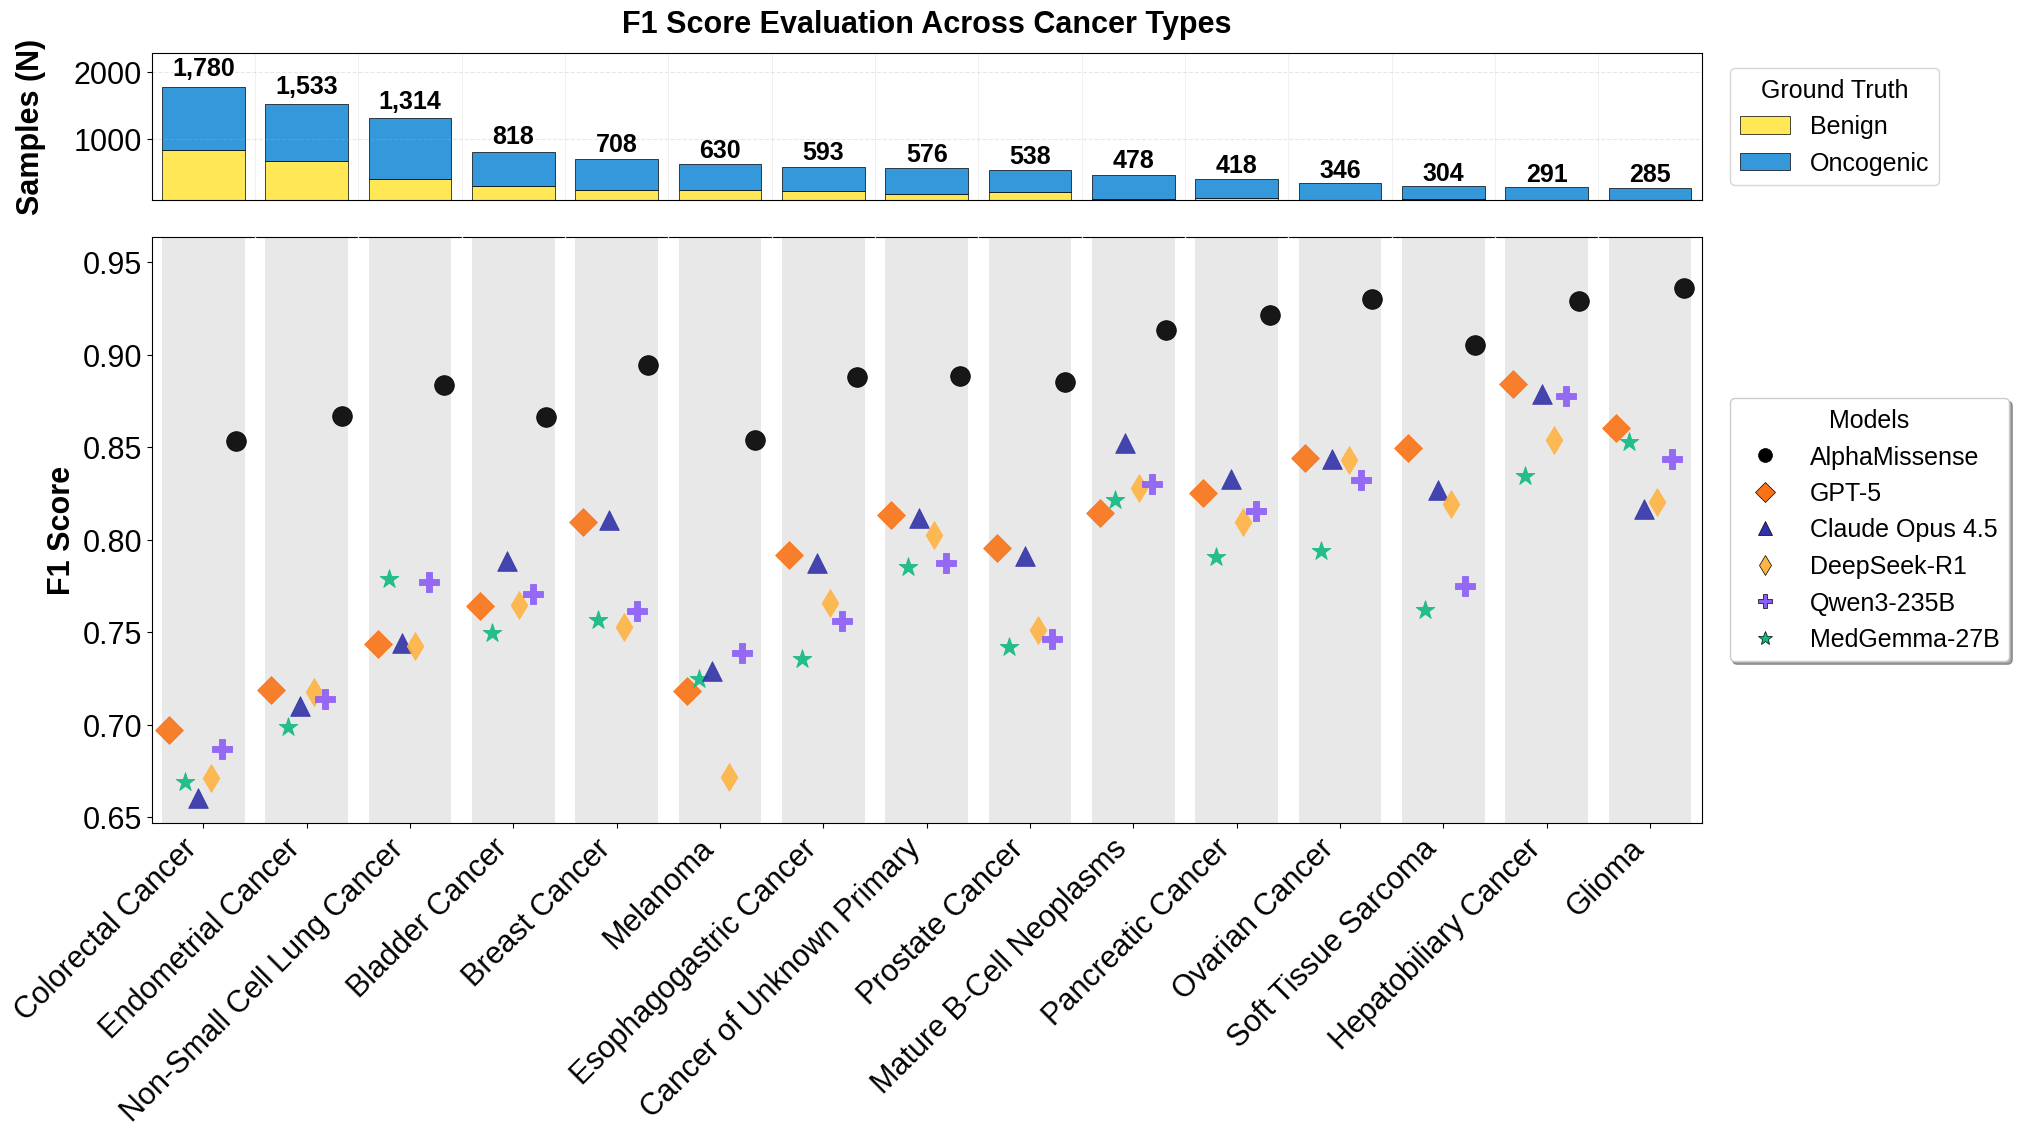

In [11]:
# Save merged dataframe
output_file = 'merged_predictions_all_models.csv'
df.to_csv(output_file, index=False)
print(f"\nSaved merged predictions to {output_file}")
print(f"Shape: {df.shape}")

# Calculate metrics
print("\nCalculating metrics by cancer type...")
metric_name = "f1"
metrics_df = calculate_metrics_by_cancer_type(df, MODEL_NAMES, ground_truth_label='ground_truth', metric=metric_name)

# Save metrics
metrics_file = f'{metric_name}_metrics_by_cancer_type.csv'
metrics_df.to_csv(metrics_file, index=False)
print(f"Saved {metric_name} metrics to {metrics_file}")

# Create visualization with custom parameters
print("\nCreating visualization...")
fig = create_accuracy_plot(
    metrics_df, 
    df,  # Pass the full dataframe for overall accuracy calculation
    top_n=15,
    jitter_amount=0.65,  # Increased jittering (0-1 scale)
    y_min=80,  # Start y-axis at 80%
    models_to_include=["AlphaMissense", "gpt-5", "claude-opus-45", "deepseek-r1", "qwen3-vl-235b-a22b", "medgemma"],
    metric=metric_name,
    legend_position='right',
    fontsize=22
)
fig.savefig("/data1/morrisq/yuj13/llm_genomics/llm_cancer_type_classification/analysis/2_oncogenic_driver_identification/plots/supp-fig2-oncogenic_driver_f1_across_cancer.pdf", bbox_inches='tight')

# Print summary
print_analysis_summary(df, metrics_df, MODEL_NAMES, ground_truth_label='ground_truth')


Calculating metrics by cancer type...
Saved accuracy metrics to accuracy_metrics_by_cancer_type.csv

Creating visualization...
{'AlphaMissense': 86.60528660528661, 'gpt-5': 77.47252747252747, 'claude-opus-45': 75.14107514107515, 'deepseek-r1': 69.91386991386992, 'qwen3-vl-235b-a22b': 68.29521829521829, 'medgemma': 65.9043659043659}


/tmp/ipykernel_3403479/2726239284.py:636: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



ANALYSIS SUMMARY

Dataset Overview:
  Total samples: 13,468
  Samples with ground truth: 13,468
  Unique cancer types: 80
  Cancer types (excl. UNKNOWN): 80

Model Coverage:               
  gpt-5               : 13,468 samples (100.0%)
  o3-mini             : 13,468 samples (100.0%)
  gpt-4o              : 13,468 samples (100.0%)
  medgemma            : 13,468 samples (100.0%)
  qwen3               : 13,468 samples (100.0%)
  claude-sonnet-37    : 13,468 samples (100.0%)
  claude-sonnet-45    : 13,468 samples (100.0%)
  claude-opus-45      : 13,468 samples (100.0%)
  deepseek            : 13,468 samples (100.0%)
  deepseek-r1         : 13,468 samples (100.0%)
  qwen3-vl-235b-a22b  : 13,468 samples (100.0%)
  AlphaMissense       : 13,468 samples (100.0%)

Overall Model Accuracy:       
  gpt-5               : 77.47%
  o3-mini             : 75.21%
  gpt-4o              : 69.39%
  medgemma            : 65.90%
  qwen3               : 65.38%
  claude-sonnet-37    : 73.11%
  claude-sonnet-

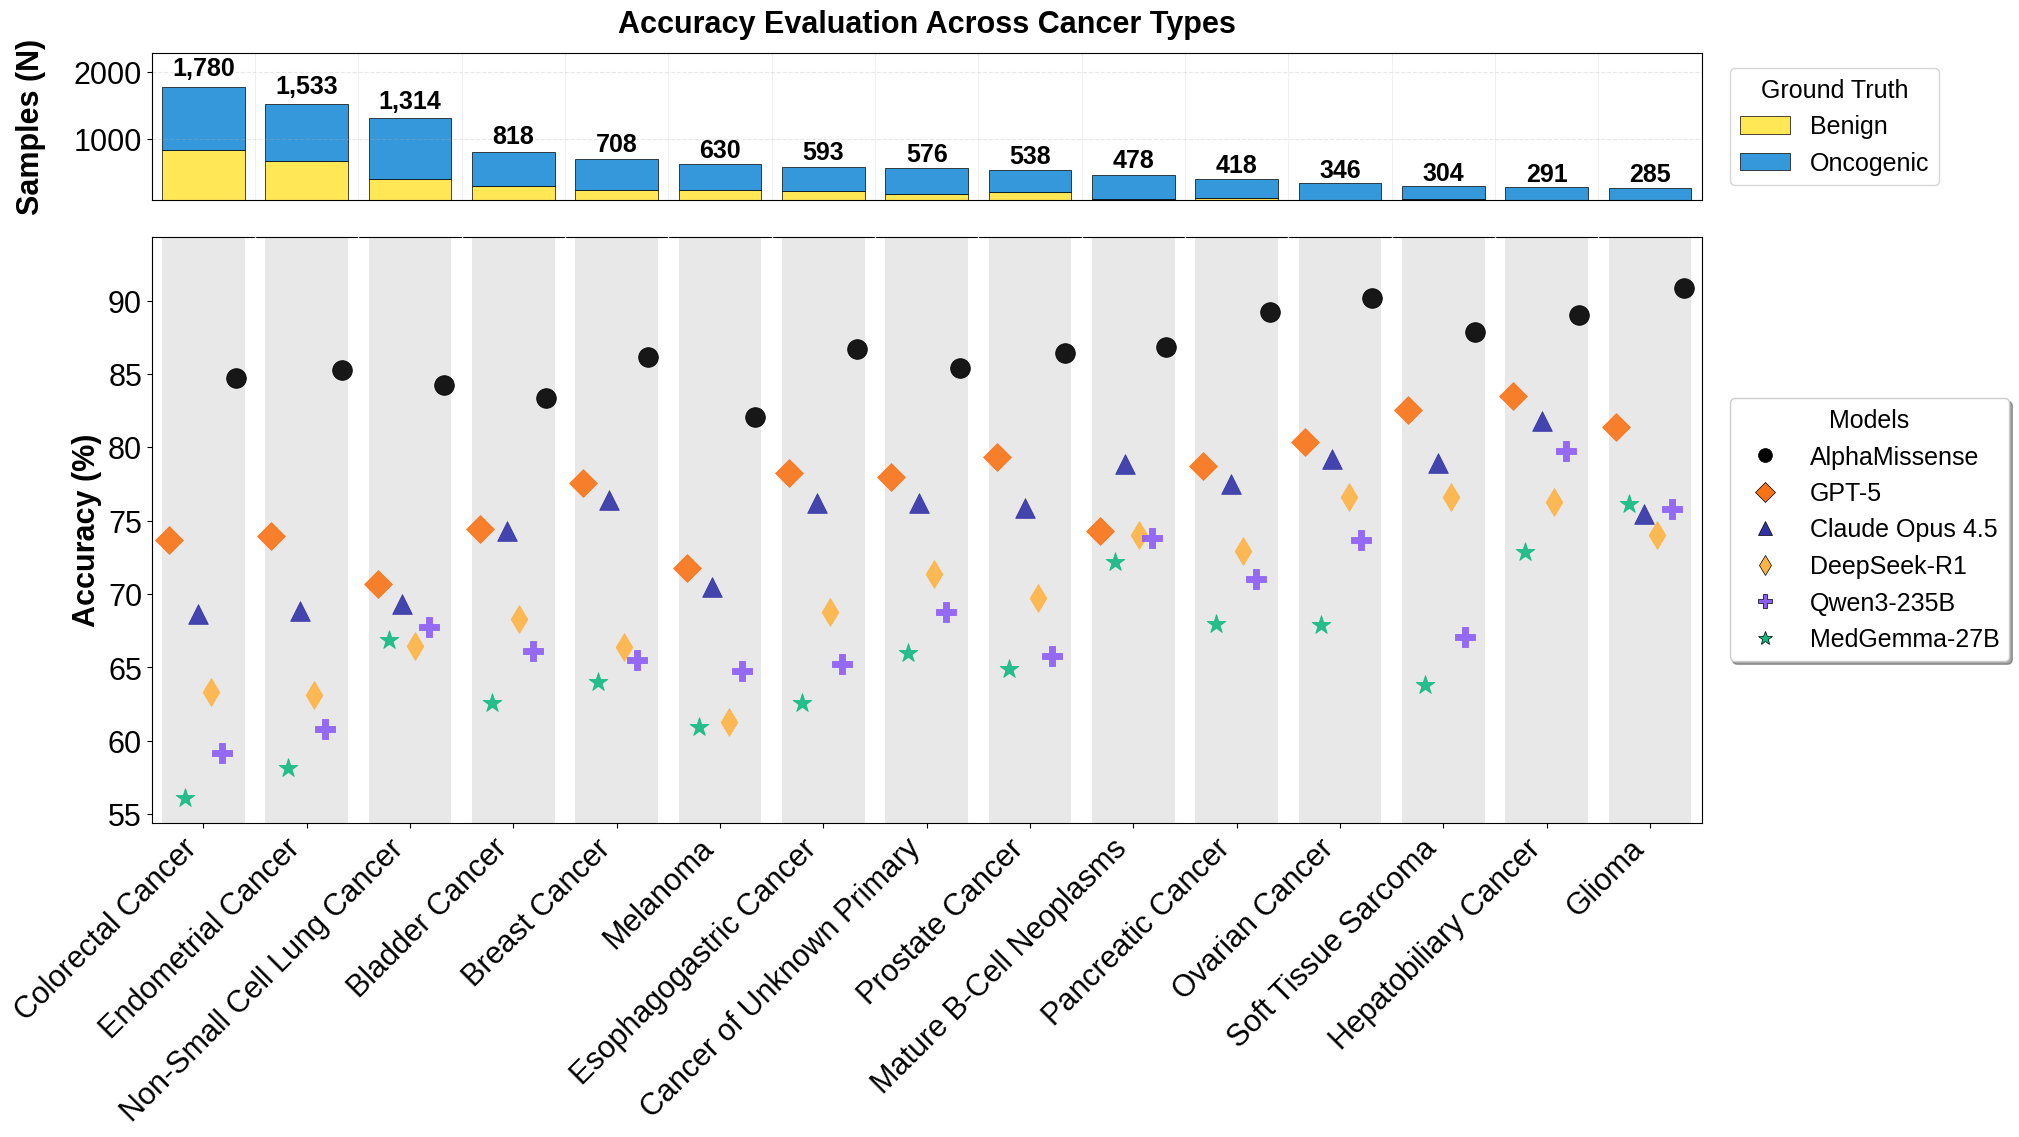

In [12]:
# Calculate metrics
print("\nCalculating metrics by cancer type...")
metric_name = "accuracy"
metrics_df = calculate_metrics_by_cancer_type(df, MODEL_NAMES, ground_truth_label='ground_truth', metric=metric_name)

# Save metrics
metrics_file = f'{metric_name}_metrics_by_cancer_type.csv'
metrics_df.to_csv(metrics_file, index=False)
print(f"Saved {metric_name} metrics to {metrics_file}")

# Create visualization with custom parameters
print("\nCreating visualization...")
fig = create_accuracy_plot(
    metrics_df, 
    df,  # Pass the full dataframe for overall accuracy calculation
    top_n=15,
    jitter_amount=0.65,  # Increased jittering (0-1 scale)
    y_min=80,  # Start y-axis at 80%
    models_to_include=["AlphaMissense", "gpt-5", "claude-opus-45", "deepseek-r1", "qwen3-vl-235b-a22b", "medgemma"],
    metric=metric_name,
    legend_position='right',
    fontsize=22
)
fig.savefig("/data1/morrisq/yuj13/llm_genomics/llm_cancer_type_classification/analysis/2_oncogenic_driver_identification/plots/supp-fig2-oncogenic_driver_accuracy_across_cancer.pdf", bbox_inches='tight')

# Print summary
print_analysis_summary(df, metrics_df, MODEL_NAMES, ground_truth_label='ground_truth')

{'AlphaMissense': 86.60528660528661, 'gpt-5': 77.47252747252747, 'claude-opus-45': 75.14107514107515, 'deepseek-r1': 69.91386991386992, 'qwen3-vl-235b-a22b': 68.29521829521829, 'medgemma': 65.9043659043659}


/tmp/ipykernel_3403479/776010318.py:458: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


{'AlphaMissense': 89.7196261682243, 'gpt-5': 80.41822641022331, 'claude-opus-45': 79.80212355212355, 'deepseek-r1': 77.89898549143668, 'qwen3-vl-235b-a22b': 78.37536716296971, 'medgemma': 77.219962297847}


/tmp/ipykernel_3403479/776010318.py:458: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


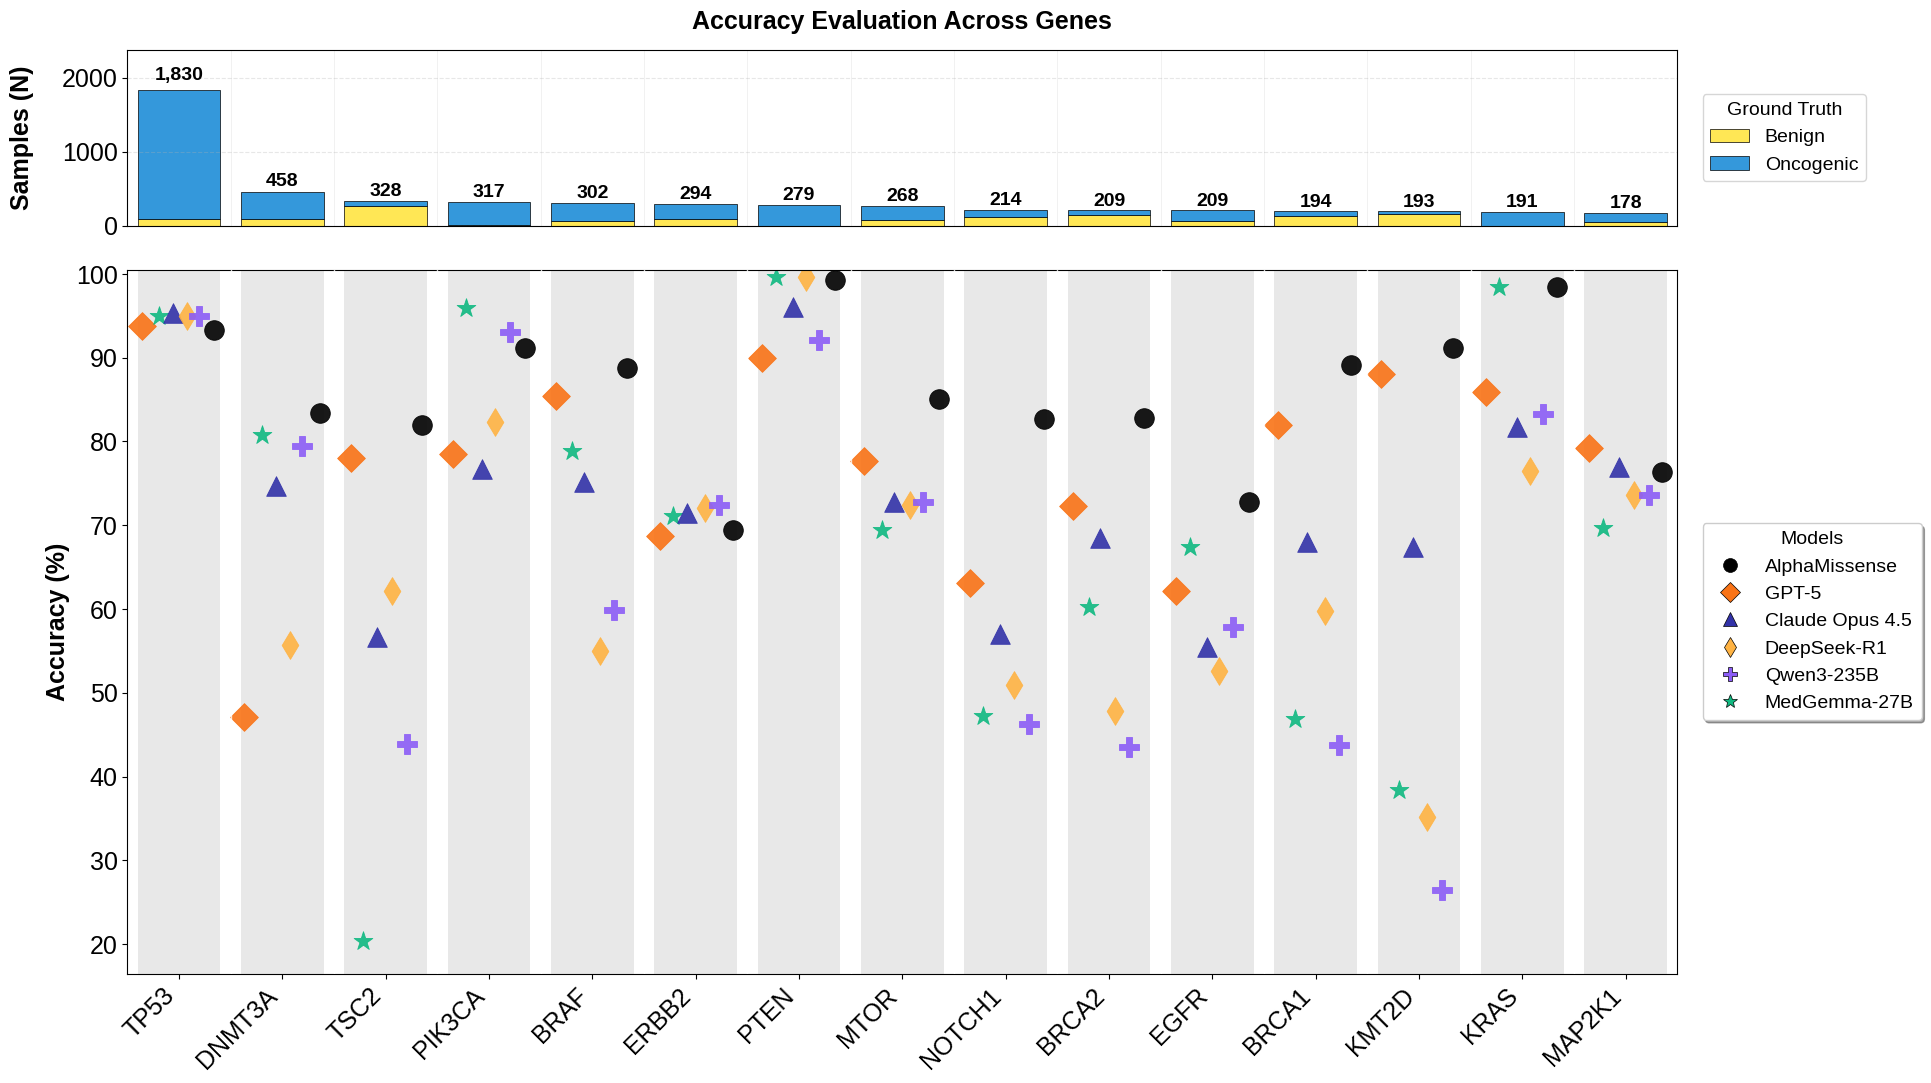

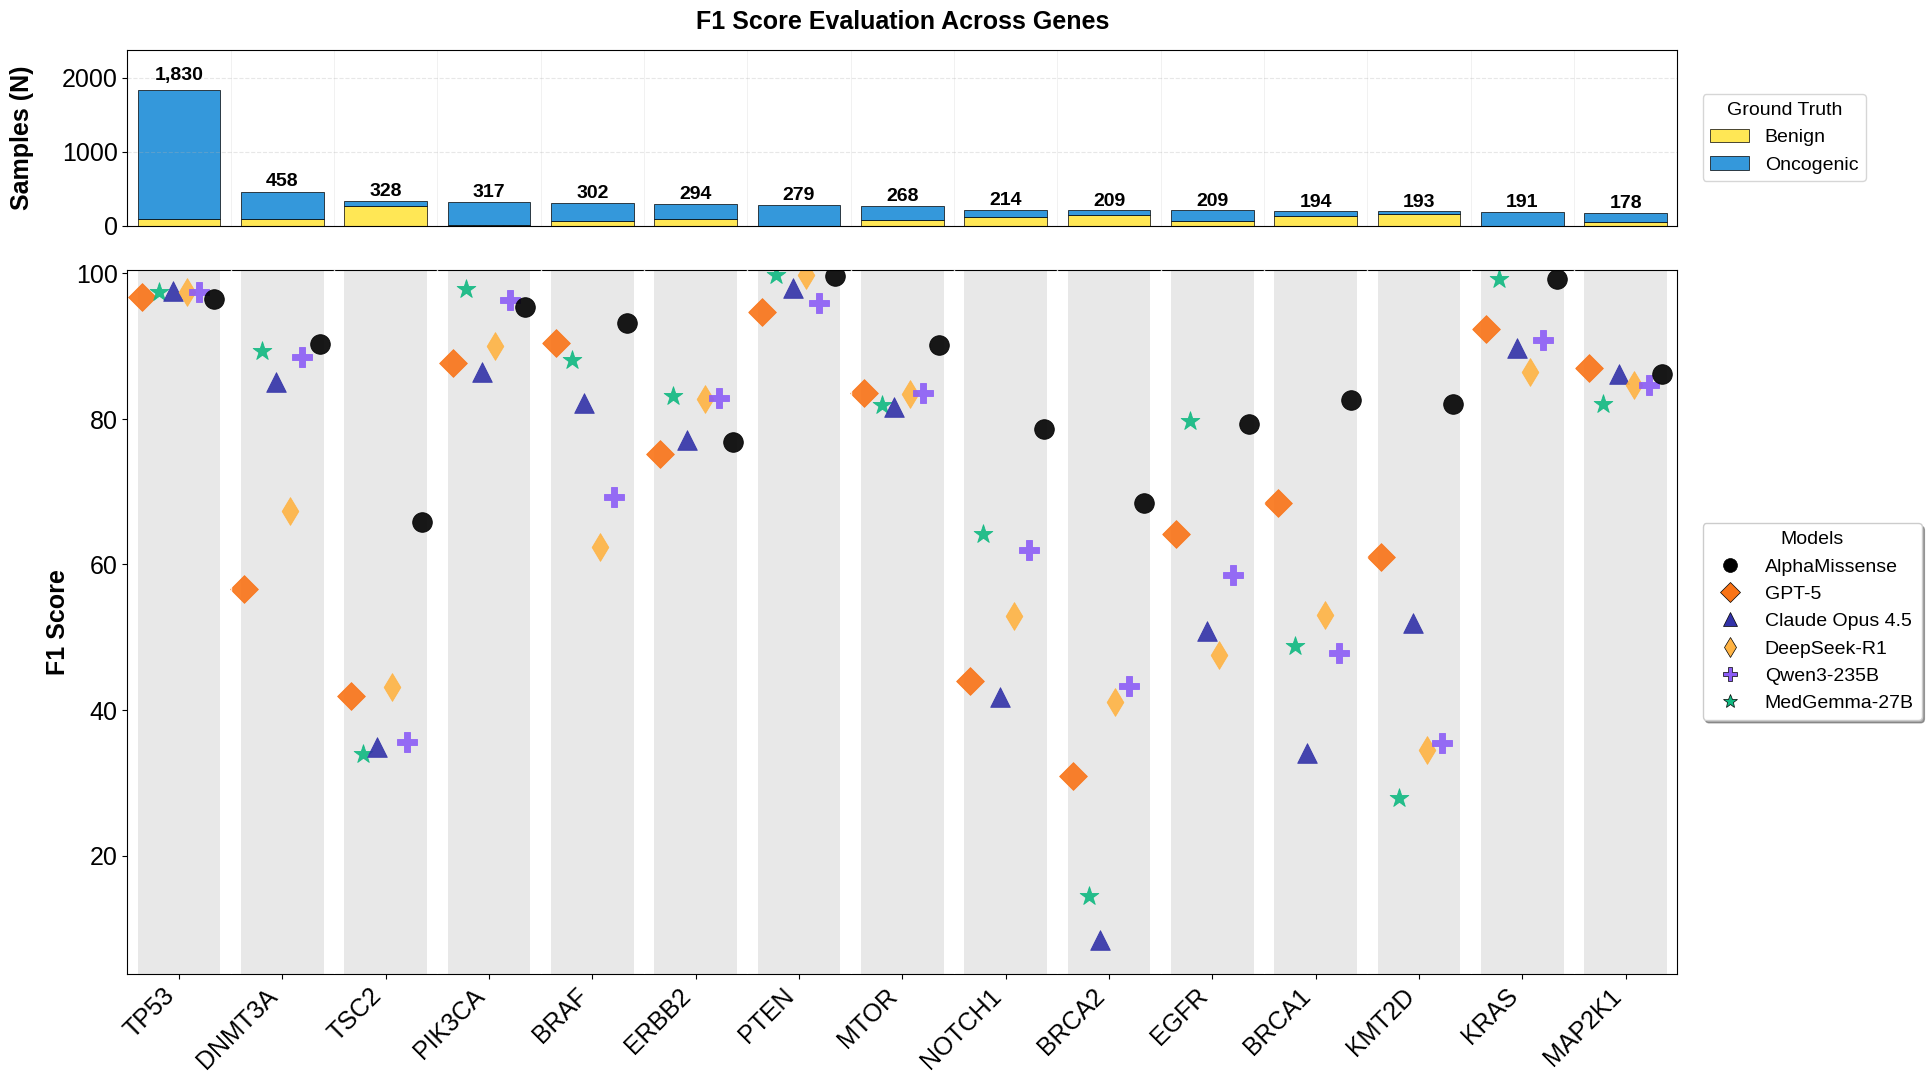

In [13]:
# Calculate metrics by gene
gene_metrics_df = calculate_metrics_by_gene(
    df, 
    MODEL_NAMES, 
    gene_col='gene',  # or 'Hugo_Symbol'
    metric='accuracy', 
    min_samples=10
)

# Create visualization
fig = create_gene_performance_plot(
    gene_metrics_df,
    df,
    gene_col='gene',  # or 'Hugo_Symbol'
    top_n=15,
    models_to_include=["AlphaMissense", "gpt-5", "claude-opus-45", "deepseek-r1", "qwen3-vl-235b-a22b", "medgemma"],
    metric='accuracy',
    legend_position='right',
    fontsize=18,
    figsize=(20, 12),
    jitter_amount=0.7
)
fig.savefig("/data1/morrisq/yuj13/llm_genomics/llm_cancer_type_classification/analysis/2_oncogenic_driver_identification/plots/supp-fig2-oncogenic_driver_accuracy_across_gene.pdf", bbox_inches='tight')

gene_metrics_df = calculate_metrics_by_gene(
    df, 
    MODEL_NAMES, 
    gene_col='gene',  # or 'Hugo_Symbol'
    metric='f1', 
    min_samples=10
)

# Create visualization
fig = create_gene_performance_plot(
    gene_metrics_df,
    df,
    gene_col='gene',  # or 'Hugo_Symbol'
    top_n=15,
    models_to_include=["AlphaMissense", "gpt-5", "claude-opus-45", "deepseek-r1", "qwen3-vl-235b-a22b", "medgemma"],
    metric='f1',
    legend_position='right',
    fontsize=18,
    figsize=(20, 12),
    jitter_amount=0.7
)
fig.savefig("/data1/morrisq/yuj13/llm_genomics/llm_cancer_type_classification/analysis/2_oncogenic_driver_identification/plots/supp-fig2-oncogenic_driver_f1_across_gene.pdf", bbox_inches='tight')


In [14]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import os

# Assuming df is already loaded from your load_all_model_predictions function

def calculate_metrics_per_model(df, model_names, ground_truth_col='OncoKB_label'):
    """
    Calculate accuracy, precision, recall, and F1 score for each model
    
    Args:
        df: DataFrame with predictions and ground truth
        model_names: List of model names
        ground_truth_col: Name of the ground truth column
    
    Returns:
        DataFrame with metrics for each model
    """
    metrics_list = []
    
    for model_name in model_names:
        pred_col = f'{model_name}_pred'
        
        # Check if prediction column exists
        if pred_col not in df.columns:
            print(f"Warning: {pred_col} not found in dataframe")
            continue
        
        # Filter out rows with missing predictions or ground truth
        valid_mask = df[pred_col].notna() & df[ground_truth_col].notna()
        df_valid = df[valid_mask].copy()
        
        if len(df_valid) == 0:
            print(f"Warning: No valid predictions for {model_name}")
            continue
        
        y_true = df_valid[ground_truth_col]
        y_pred = df_valid[pred_col]
        
        # Calculate metrics
        # For binary classification (Oncogenic vs not)
        try:
            accuracy = accuracy_score(y_true, y_pred)
            
            # Check if binary or multiclass
            unique_labels = sorted(y_true.unique())
            
            if len(unique_labels) == 2:
                # Binary classification
                precision = precision_score(y_true, y_pred, pos_label=unique_labels[1], zero_division=0)
                recall = recall_score(y_true, y_pred, pos_label=unique_labels[1], zero_division=0)
                f1 = f1_score(y_true, y_pred, pos_label=unique_labels[1], zero_division=0)
            else:
                # Multiclass - use weighted average
                precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
                recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
                f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
            
            metrics_list.append({
                'model': model_name,
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1_score': f1,
                'n_samples': len(df_valid),
                'n_classes': len(unique_labels)
            })
            
            print(f"\n{model_name}:")
            print(f"  Samples: {len(df_valid)}")
            print(f"  Accuracy: {accuracy:.4f}")
            print(f"  Precision: {precision:.4f}")
            print(f"  Recall: {recall:.4f}")
            print(f"  F1 Score: {f1:.4f}")
            
        except Exception as e:
            print(f"Error calculating metrics for {model_name}: {e}")
            continue
    
    # Create metrics dataframe
    metrics_df = pd.DataFrame(metrics_list)
    
    return metrics_df


def calculate_detailed_metrics_per_model(df, model_names, ground_truth_col='OncoKB_label'):
    """
    Calculate detailed metrics including per-class metrics
    
    Args:
        df: DataFrame with predictions and ground truth
        model_names: List of model names
        ground_truth_col: Name of the ground truth column
    
    Returns:
        Dictionary with detailed metrics for each model
    """
    detailed_metrics = {}
    
    for model_name in model_names:
        pred_col = f'{model_name}_pred'
        
        if pred_col not in df.columns:
            continue
        
        # Filter valid predictions
        valid_mask = df[pred_col].notna() & df[ground_truth_col].notna()
        df_valid = df[valid_mask].copy()
        
        if len(df_valid) == 0:
            continue
        
        y_true = df_valid[ground_truth_col]
        y_pred = df_valid[pred_col]
        
        # Generate classification report
        report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
        
        detailed_metrics[model_name] = {
            'classification_report': report,
            'n_samples': len(df_valid)
        }
        
        print(f"\n{'='*60}")
        print(f"Detailed Metrics for {model_name}")
        print(f"{'='*60}")
        print(classification_report(y_true, y_pred, zero_division=0))
    
    return detailed_metrics


# Calculate metrics
print("\n" + "="*60)
print("CALCULATING METRICS FOR ALL MODELS")
print("="*60)

metrics_df = calculate_metrics_per_model(df, MODEL_NAMES, ground_truth_col='ground_truth')

# Save metrics to CSV
os.makedirs(OUT_METRICS_DIR, exist_ok=True)
metrics_output_path = os.path.join(OUT_METRICS_DIR, "model_performance_metrics.csv")
metrics_df.to_csv(metrics_output_path, index=False)
print(f"\nMetrics saved to: {metrics_output_path}")

# Calculate detailed metrics
detailed_metrics = calculate_detailed_metrics_per_model(df, MODEL_NAMES, ground_truth_col='ground_truth')

# Save detailed metrics summary
detailed_summary = []
for model_name, metrics in detailed_metrics.items():
    report = metrics['classification_report']
    detailed_summary.append({
        'model': model_name,
        'accuracy': report['accuracy'],
        'macro_avg_precision': report['macro avg']['precision'],
        'macro_avg_recall': report['macro avg']['recall'],
        'macro_avg_f1': report['macro avg']['f1-score'],
        'weighted_avg_precision': report['weighted avg']['precision'],
        'weighted_avg_recall': report['weighted avg']['recall'],
        'weighted_avg_f1': report['weighted avg']['f1-score'],
        'n_samples': metrics['n_samples']
    })

detailed_summary_df = pd.DataFrame(detailed_summary)
detailed_output_path = os.path.join(OUT_METRICS_DIR, "model_performance_detailed.csv")
detailed_summary_df.to_csv(detailed_output_path, index=False)
print(f"Detailed metrics saved to: {detailed_output_path}")

# Display summary
print("\n" + "="*60)
print("SUMMARY OF ALL MODELS")
print("="*60)
print(metrics_df.to_string(index=False))


CALCULATING METRICS FOR ALL MODELS

gpt-5:
  Samples: 13468
  Accuracy: 0.7747
  Precision: 0.9329
  Recall: 0.7067
  F1 Score: 0.8042

o3-mini:
  Samples: 13468
  Accuracy: 0.7521
  Precision: 0.7868
  Recall: 0.8522
  F1 Score: 0.8182

gpt-4o:
  Samples: 13468
  Accuracy: 0.6939
  Precision: 0.8041
  Recall: 0.7037
  F1 Score: 0.7506

medgemma:
  Samples: 13468
  Accuracy: 0.6590
  Precision: 0.6862
  Recall: 0.8828
  F1 Score: 0.7722

qwen3:
  Samples: 13468
  Accuracy: 0.6538
  Precision: 0.6558
  Recall: 0.9915
  F1 Score: 0.7894

claude-sonnet-37:
  Samples: 13468
  Accuracy: 0.7311
  Precision: 0.8012
  Recall: 0.7837
  F1 Score: 0.7924

claude-sonnet-45:
  Samples: 13468
  Accuracy: 0.6773
  Precision: 0.7774
  Recall: 0.7105
  F1 Score: 0.7424

claude-opus-45:
  Samples: 13468
  Accuracy: 0.7514
  Precision: 0.8523
  Recall: 0.7502
  F1 Score: 0.7980

deepseek:
  Samples: 13468
  Accuracy: 0.6584
  Precision: 0.6584
  Recall: 0.9936
  F1 Score: 0.7920

deepseek-r1:
  Samples:

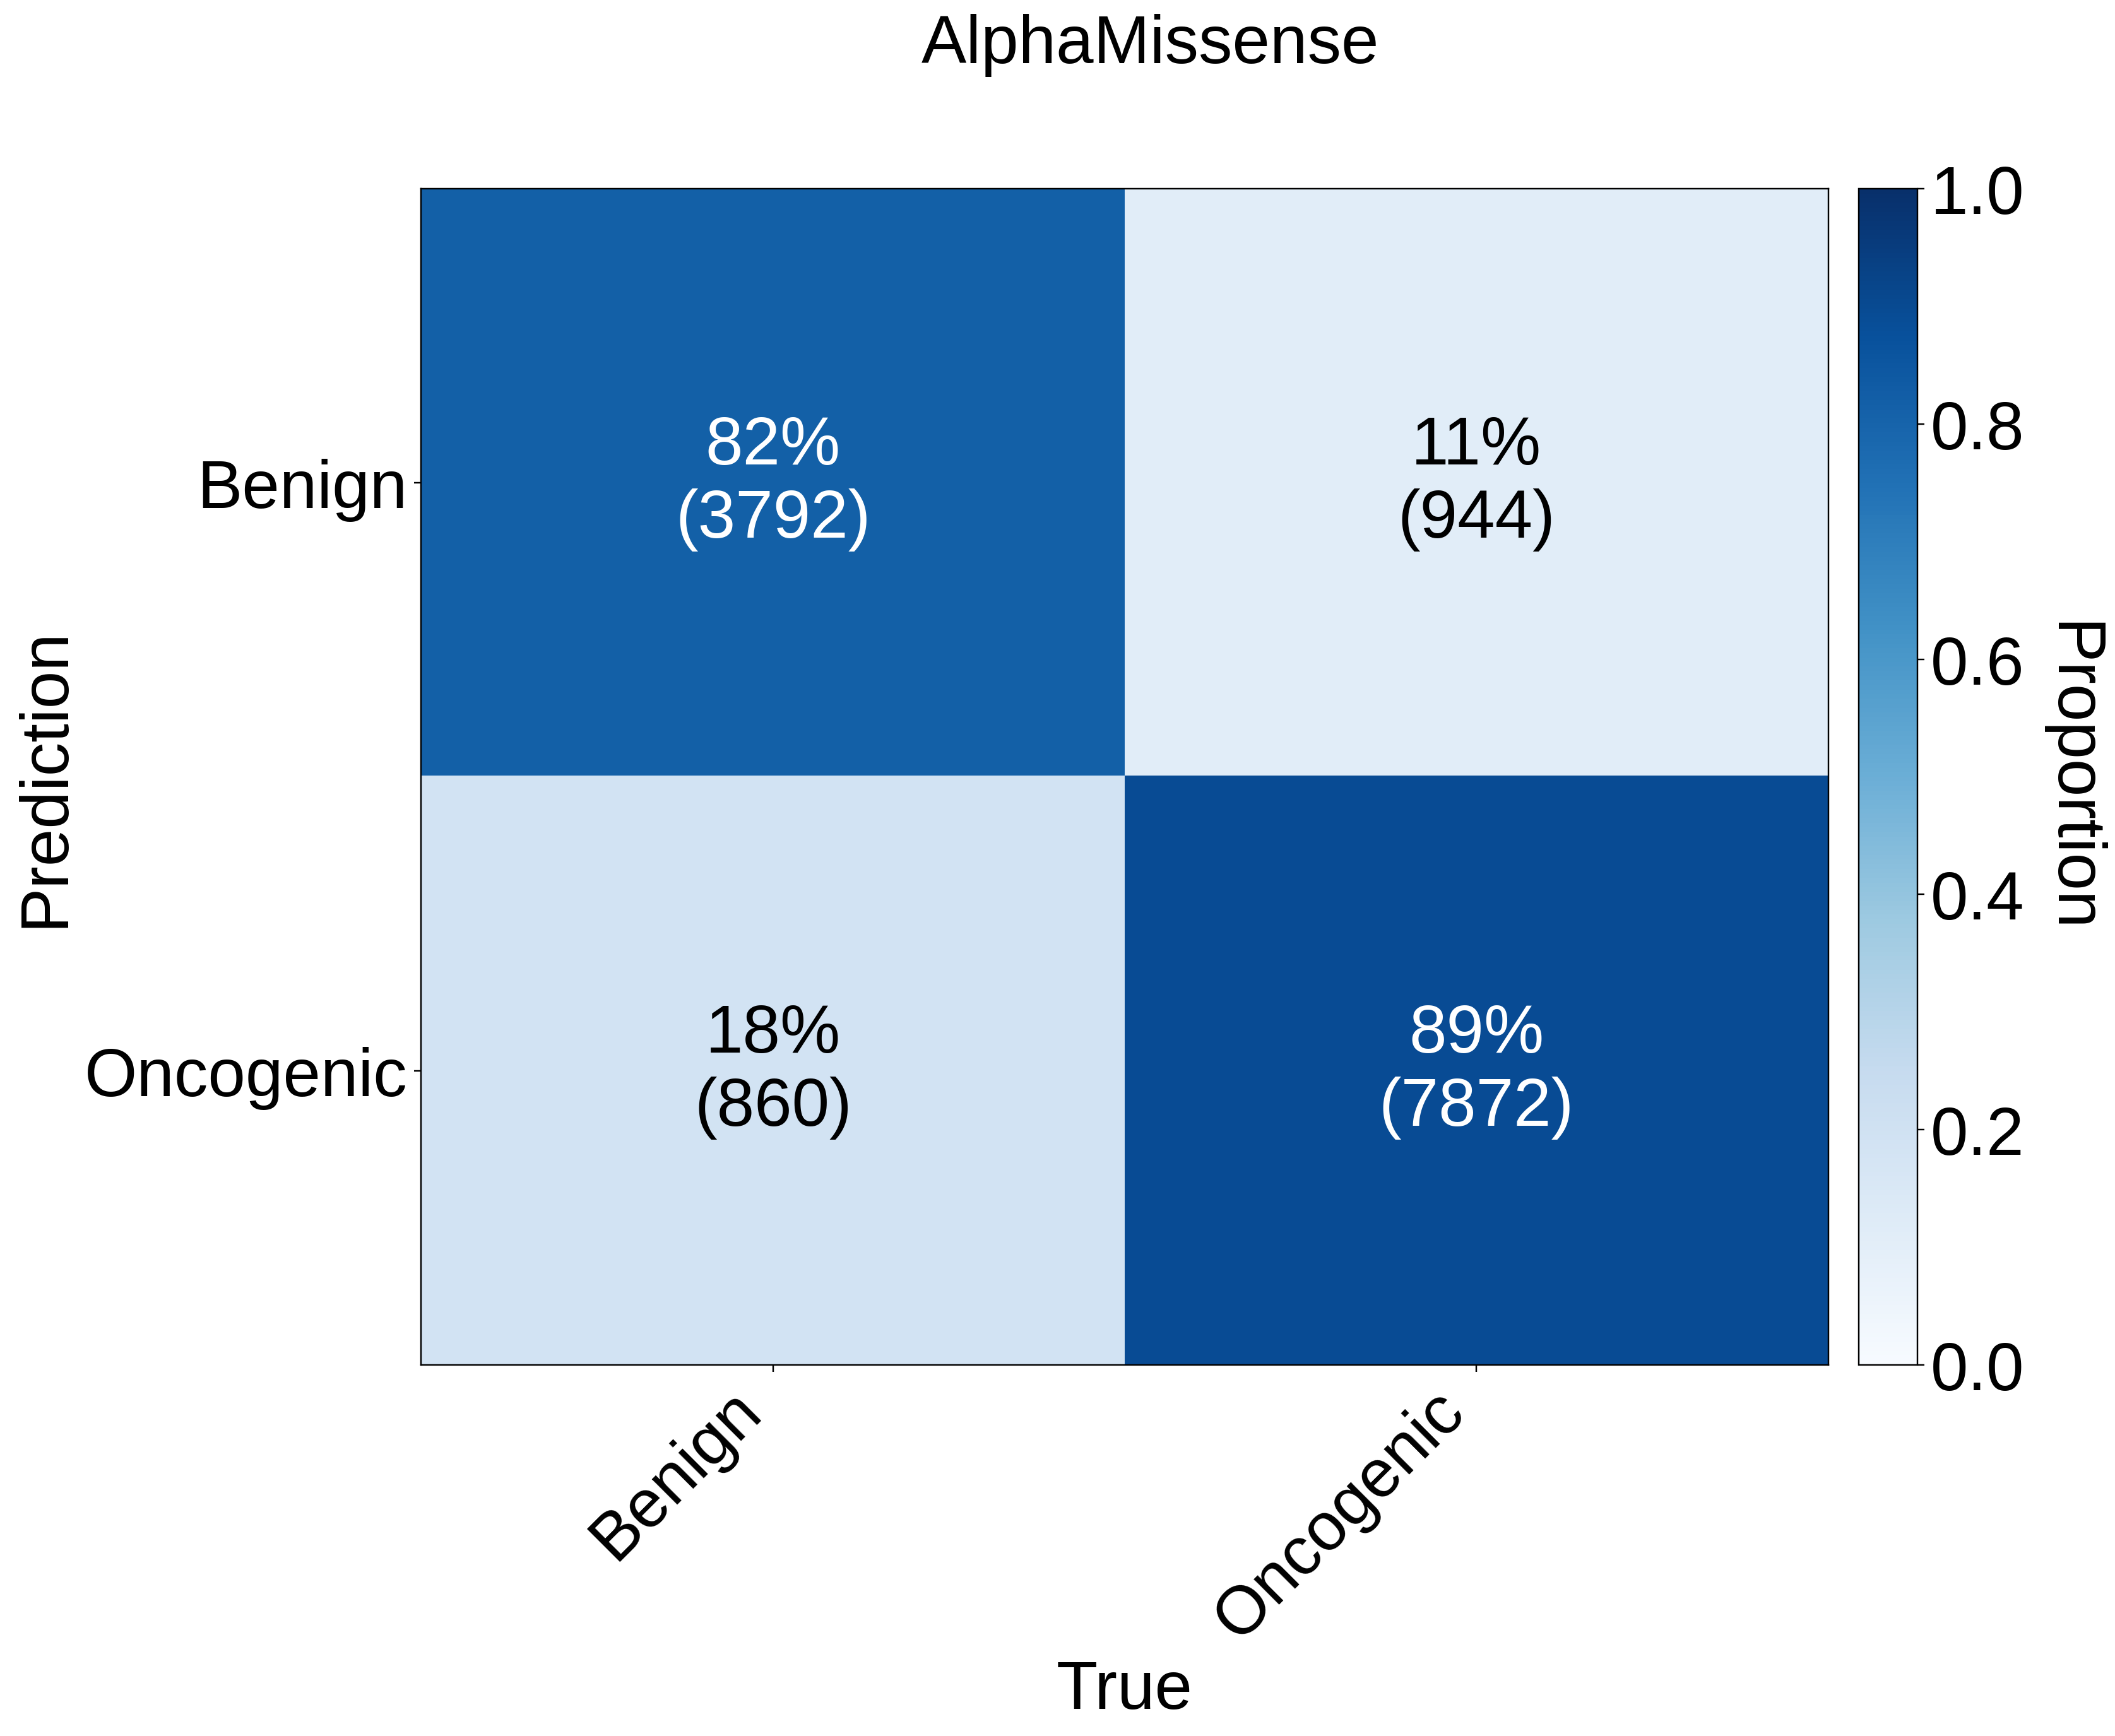

In [15]:
import numpy as np
import pandas as pd
import unicodedata
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, Normalize

def plot_confusion_with_pr(
    df,
    true_col="ground_truth",
    pred_col="gpt-5_pred",
    prob_col=None,
    normalize="true",               # 'true' | 'pred' | 'all' | None
    threshold=0.5,
    label_order=None,
    normalize_labels=True,
    sort_by_diagonal=True,
    show_recall=False,
    show_precision=False,
    show_colorbar=True,
    diverging=False,                # keep False to use single-hue
    cmap="Blues",
    cbar_limits=(0, 1),
    annot_decimals=0,
    auto_contrast_annots=True,
    annot_dark="white",
    annot_light="black",
    contrast_threshold=0.5,
    figsize=(14, 11),
    fonts=None,
    title="Confusion Matrix",
    cols_from_true_only=True,       # <<< NEW: keep only ground-truth columns
    fig_path=None
):
    fonts = fonts or {'title':18,'axis':12,'tick':11,'annot':18,'legend':9}

    def _norm_name(s):
        if not isinstance(s, str): return s
        s = unicodedata.normalize("NFKD", s)
        return (s.replace('‐','-').replace('–','-').replace('—','-')
                 .replace(',', '').strip())

    data = df.copy()
    if normalize_labels:
        data[true_col] = data[true_col].map(_norm_name)
        data[pred_col] = data[pred_col].map(_norm_name)

    # --- Labels (separate sets so we can be rectangular) ---
    if label_order is None:
        true_labels = sorted(pd.Index(data[true_col]).dropna().unique().tolist())
        pred_labels = sorted(pd.Index(data[pred_col]).dropna().unique().tolist())
    else:
        order = list(label_order)
        true_seen = set(pd.Index(data[true_col]).dropna().unique().tolist())
        pred_seen = set(pd.Index(data[pred_col]).dropna().unique().tolist())
        true_labels = [x for x in order if x in true_seen] + sorted(true_seen - set(order))
        pred_labels = [x for x in order if x in pred_seen] + sorted(pred_seen - set(order))

    # If requested, keep only GT columns even if preds contain extra classes
    if cols_from_true_only:
        # columns stay as true_labels; rows are all pred_labels (including extras like VUS)
        pass  # behavior is achieved by how we build the crosstab below

    # --- Rectangular counts via crosstab (pred rows × true columns) ---
    data_true = pd.Categorical(data[true_col], categories=true_labels, ordered=True)
    data_pred = pd.Categorical(data[pred_col], categories=pred_labels, ordered=True)
    cm_counts_df = pd.crosstab(data_pred, data_true, dropna=False).fillna(0).astype(int)

    # --- Normalization to match sklearn semantics with our axes ---
    if normalize is None:
        cm_norm_df = None
    elif normalize == "true":       # normalize by ground-truth => column-wise
        denom = cm_counts_df.sum(axis=0).replace(0, np.nan)
        cm_norm_df = cm_counts_df.divide(denom, axis=1).fillna(0.0)
    elif normalize == "pred":       # normalize by prediction => row-wise
        denom = cm_counts_df.sum(axis=1).replace(0, np.nan)
        cm_norm_df = cm_counts_df.divide(denom, axis=0).fillna(0.0)
    elif normalize == "all":
        total = cm_counts_df.values.sum()
        cm_norm_df = cm_counts_df / total if total else cm_counts_df.astype(float)
    else:
        raise ValueError("normalize must be one of {'true','pred','all',None}")

    # --- Optional sorting by (matched) diagonal strength ---
    if sort_by_diagonal:
        # score for each pred label = value at [label,label] if label exists in columns
        src = cm_norm_df if cm_norm_df is not None else cm_counts_df.astype(float)
        pred_scores = [float(src.loc[l, l]) if l in src.columns else -1.0 for l in src.index]
        true_scores = [float(src.loc[l, l]) if l in src.index else -1.0 for l in src.columns]
        pred_order = np.argsort(pred_scores)[::-1]
        true_order = np.argsort(true_scores)[::-1]
        cm_counts_df = cm_counts_df.iloc[pred_order, true_order]
        if cm_norm_df is not None:
            cm_norm_df = cm_norm_df.iloc[pred_order, true_order]

    labels_y = cm_counts_df.index.tolist()   # prediction labels (rows)
    labels_x = cm_counts_df.columns.tolist() # ground-truth labels (cols)

    matrix = (cm_norm_df.values if cm_norm_df is not None
              else cm_counts_df.values.astype(float))

    # --- Color normalization ---
    if cm_norm_df is not None:
        norm = (TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1) if diverging
                else Normalize(vmin=cbar_limits[0], vmax=cbar_limits[1]))
    else:
        norm = None  # raw counts (auto-scaled by Matplotlib)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize, dpi=220)
    im = ax.imshow(matrix, cmap=cmap, norm=norm, aspect='auto')
    ax.set_xlabel("True", fontsize=fonts['axis'])
    ax.set_ylabel("Prediction", fontsize=fonts['axis'])
    ax.set_xticks(range(len(labels_x))); ax.set_yticks(range(len(labels_y)))
    ax.set_xticklabels(labels_x, rotation=45, ha='right', fontsize=fonts['tick'])
    ax.set_yticklabels(labels_y, fontsize=fonts['tick'])

    # --- Auto-contrast helper ---
    def _rel_lum(rgb):
        r, g, b = rgb[:3]
        def f(c): return c/12.92 if c <= 0.03928 else ((c+0.055)/1.055)**2.4
        R, G, B = f(r), f(g), f(b)
        return 0.2126*R + 0.7152*G + 0.0722*B

    # --- Annotations ---
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            raw = cm_counts_df.values[i, j]
            if cm_norm_df is None:
                s = f"{raw}" if raw else ""
            else:
                pct = matrix[i, j] * 100
                s = "" if (raw == 0 and pct == 0) else f"{pct:.{annot_decimals}f}%\n({raw})"
            if not s:
                continue
            rgba = im.cmap(im.norm(matrix[i, j]))
            lum = _rel_lum(rgba)
            tcolor = annot_dark if auto_contrast_annots and lum < contrast_threshold else annot_light
            ax.text(j, i, s, ha='center', va='center', fontsize=fonts['annot'], color=tcolor)

    if show_colorbar:
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
        cbar.ax.set_ylabel("Proportion" if cm_norm_df is not None else "Count",
                           rotation=270, labelpad=40, fontsize=fonts['axis'])
        cbar.ax.tick_params(labelsize=fonts['tick'])

    fig.suptitle(title, fontsize=fonts['title'], y=0.995)
    if fig_path:
        plt.savefig(fig_path, bbox_inches='tight')
    plt.show()


# -------------------------
# EXAMPLES
# -------------------------

plot_confusion_with_pr(
    df,
    true_col="ground_truth",
    pred_col="AlphaMissense_pred",
    prob_col="AlphaMissense_prob",
    threshold=0.5,
    cmap="Blues",
    fonts={'title':35,'axis':35,'tick':35,'annot':35,'legend':20},
    show_recall=False,
    show_precision=False,
    title="AlphaMissense",
    sort_by_diagonal=False,
    fig_path="/data1/morrisq/yuj13/llm_genomics/llm_cancer_type_classification/analysis/2_oncogenic_driver_identification/plots/supp-fig1-oncogenic_driver_AlphaMissense.pdf"
)


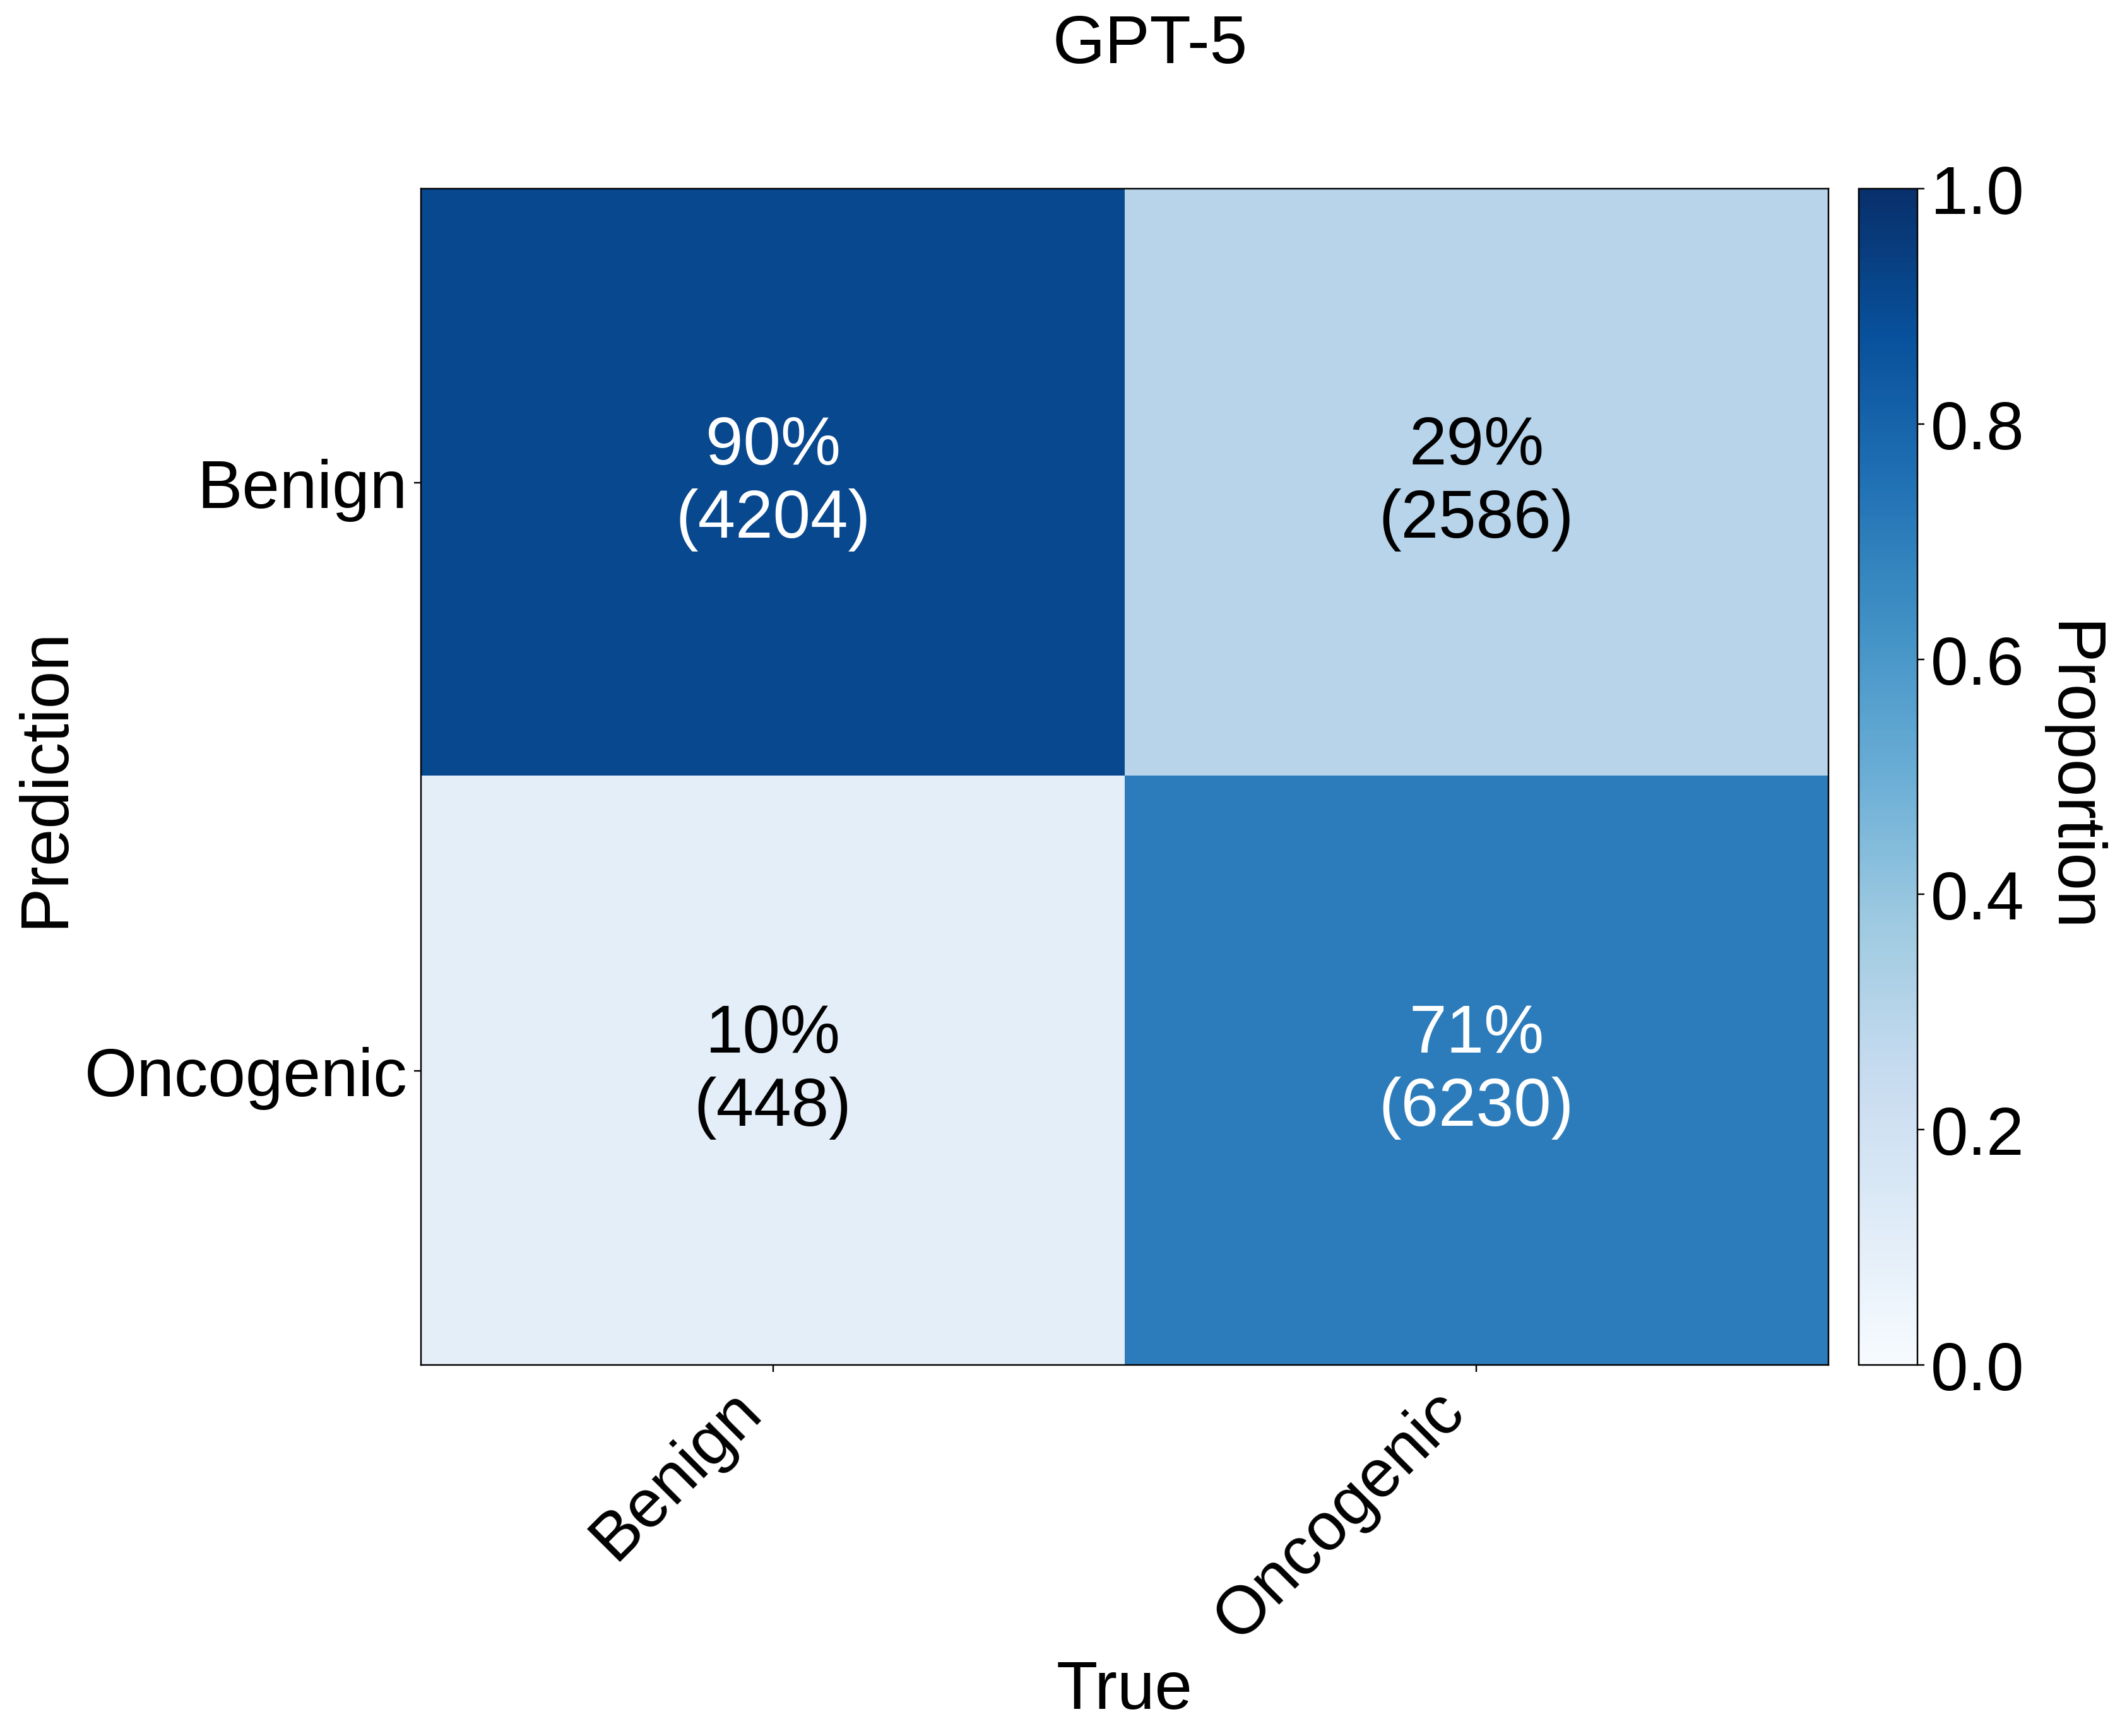

In [16]:
plot_confusion_with_pr(
    df,
    true_col="ground_truth",
    pred_col="gpt-5_pred",
    prob_col="gpt-5_prob",
    threshold=0.5,
    cmap="Blues",
    fonts={'title':35,'axis':35,'tick':35,'annot':35,'legend':20},
    # show_recall=True,
    # show_precision=True,
    title="GPT-5",
    sort_by_diagonal=False,
    fig_path="/data1/morrisq/yuj13/llm_genomics/llm_cancer_type_classification/analysis/2_oncogenic_driver_identification/plots/supp-fig1-oncogenic_driver_gpt5.pdf"
)

In [17]:
df['gpt-5_pred'].value_counts()

gpt-5_pred
Benign       6790
Oncogenic    6678
Name: count, dtype: int64

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import List, Optional, Dict, Tuple
import os
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
from matplotlib import font_manager, rcParams
from matplotlib.lines import Line2D

# Path to your font directory
font_dir = "/data1/morrisq/yuj13/share/fonts/liberation-fonts-ttf-2.1.5/"

# Register the font files with Matplotlib
font_manager.fontManager.addfont(font_dir + "LiberationSans-Regular.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Bold.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Italic.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-BoldItalic.ttf")

# Set Liberation Sans as the default font (Arial-compatible)
rcParams["font.family"] = "Liberation Sans"

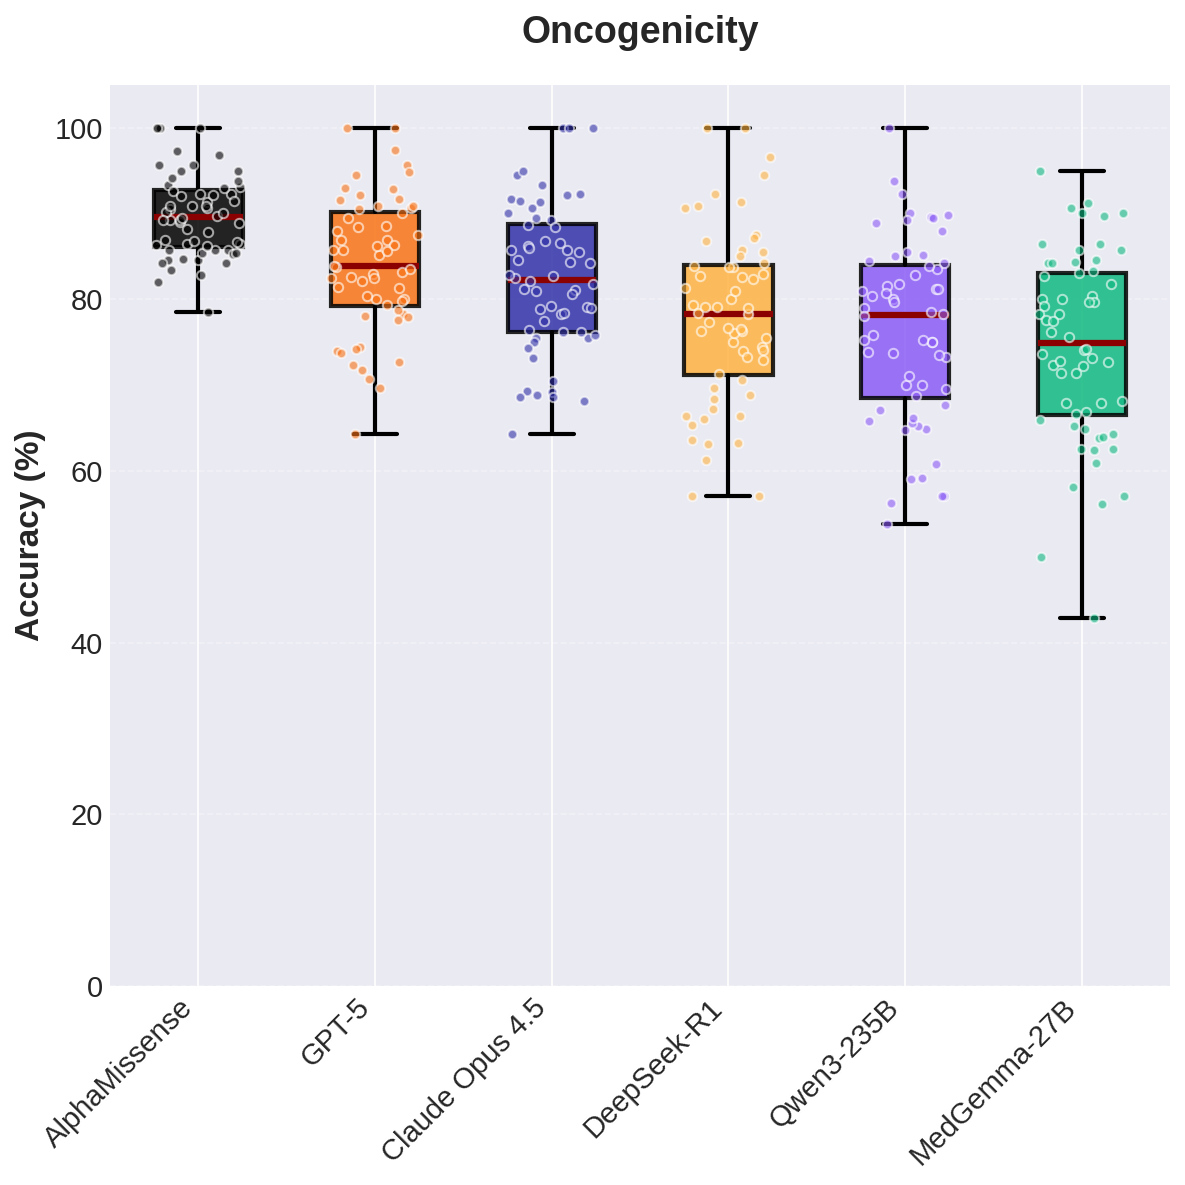

In [19]:
# Example: Create box plot showing distribution of accuracy across cancer types for each model
# This assumes you have already calculated metrics_df using calculate_metrics_by_cancer_type

# Calculate accuracy metrics by cancer type (if not already done)
metric_name = 'accuracy'
metrics_df = calculate_metrics_by_cancer_type(df, MODEL_NAMES, metric=metric_name)

# Create the box plot
fig = create_model_boxplot_with_dots(
    metrics_df=metrics_df,
    metric_col=metric_name,  # or 'f1', 'precision', 'recall'
    models_to_include=["AlphaMissense", "gpt-5", "claude-opus-45", "deepseek-r1", "qwen3-vl-235b-a22b", "medgemma"],
    figsize=(8, 8),
    fontsize=14,
    dot_alpha=0.6,
    dot_size=20,
    jitter_strength=0.25,
    y_lim=(0, 105),
    title='Oncogenicity'
)

plt.show()

# Save the figure
fig.savefig('oncogenic_driver_accuracy.pdf', dpi=300, bbox_inches='tight')

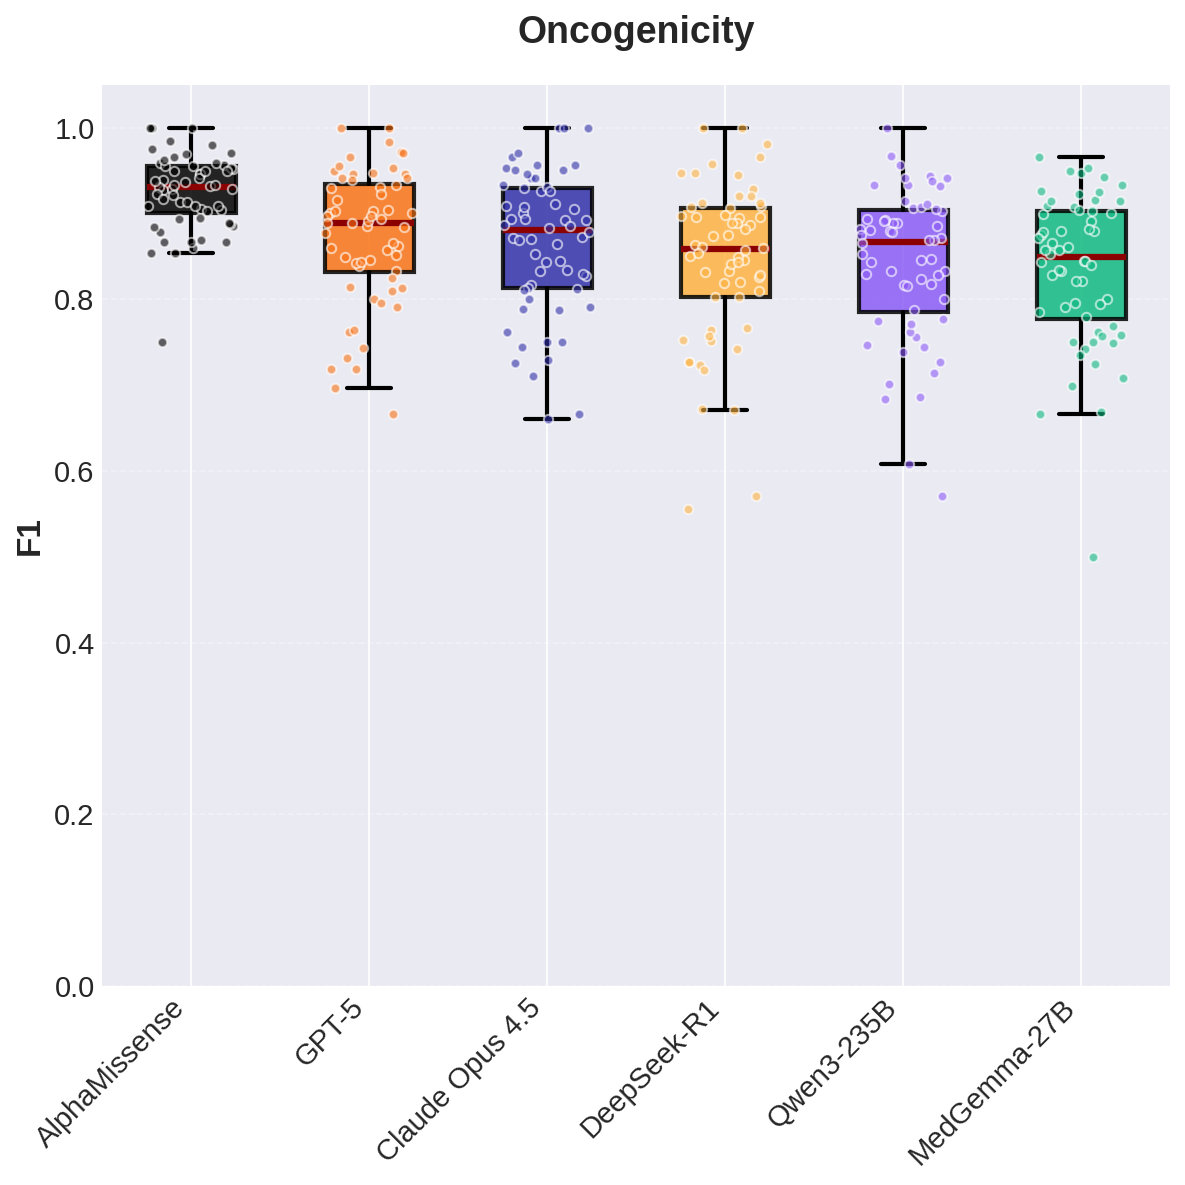

In [20]:
# Calculate accuracy metrics by cancer type (if not already done)
metric_name = 'f1'
metrics_df = calculate_metrics_by_cancer_type(df, MODEL_NAMES, metric=metric_name)

# Create the box plot
fig = create_model_boxplot_with_dots(
    metrics_df=metrics_df,
    metric_col=metric_name,  # or 'f1', 'precision', 'recall'
    models_to_include=["AlphaMissense", "gpt-5", "claude-opus-45", "deepseek-r1", "qwen3-vl-235b-a22b", "medgemma"],
    figsize=(8, 8),
    fontsize=14,
    dot_alpha=0.6,
    dot_size=20,
    jitter_strength=0.25,
    y_lim=(0, 1.05),
    title='Oncogenicity'
)

plt.show()
# Save the figure
fig.savefig('oncogenic_driver_f1.pdf', dpi=300, bbox_inches='tight')